<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GN_GGN_PFE_Domestic_Journal_Robust_Verification_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 국내 등재학술지 보완본: 교차검증된 GN/GGN 모델 기반 PFE 제약 해저 HCF 시스템의 강건 설계

## HCF · G.652.D · G.654.E — 정확도, 수렴성, 손익분기 및 불확실성 분석

이 Colab은 기존 GN/GGN 문헌 교차검증 노트북을 보존하면서 국내 등재학술지 투고에 필요한 추가 검증을 한 파일에 통합한다.

### 추가 기여

1. Cartesian GN frequency-grid 수렴성과 계산시간을 정량화한다.
2. 대표 3채널 단일-span scalar SSFM으로 waveform-level 독립 sanity check를 수행한다.
3. 15,000 km, 12 FP, 18 kV 조건에서 span–launch-power–GSNR 설계 지도를 작성한다.
4. EDFA 전기–광 효율 2.0/2.5/3.1/4.0%와 gain/output-dependent surrogate, PFE 12/15/18 kV를 비교한다.
5. HCF attenuation–IMI 평면에서 G.654.E 대비 GSNR 및 중계기 손익분기 경계를 계산한다.
6. HCF/G.654.E 제조·운용 편차를 Monte Carlo로 전파하여 95% 구간과 우위 확률을 제시한다.
7. 이상적 Shannon capacity와 repeater electrical energy/bit를 보조 지표로 계산한다.

> 모델 한계: generalized GN(GGN)은 SRS/power-profile 모델이며 modulation-statistics EGN의 대체물이 아니다. SSFM 셀은 full-field 해저 링크 실험의 대체가 아니라 대표 단일-span 독립 검산이다. Monte Carlo 분포는 예시 prior이며 실제 제조·측정 통계로 교체해야 최종 논문 수치가 된다.


## 0. 검증 원칙과 판정 기준

- 원 코드의 폐형식 GN은 수정하지 않고 동일 식으로 호출한다.
- MATLAB 이식판은 저장소의 단위 규약(주파수 THz, 거리 km, $\beta_2$ ps²/km, PSD W/THz)을 따른다.
- `GNLI_f_hyp.m`은 이름과 달리 `GNLI_f.m` 호출 래퍼이므로 별도 hyperbolic-domain 적분으로 간주하지 않는다.
- `GGNLI_f_3.m`도 `GGNLI_f.m` 호출 래퍼이며, 원문 `GGNLI_f.m`에는 `sys.Ns`가 사용되지 않는다.
- 논문 곡선은 제공 PDF의 래스터 Figure에서 지정된 $N_{span}$ 또는 $\Delta f$ 위치를 좌표화했다. 선 두께를 고려한 판독 불확도는 Figure 1·2 약 ±0.3 dB, Figure 3 약 ±0.1 dB-reach 수준이다.
- Figure 3의 오차는 논문 표현에 맞춰 $10\log_{10}(N_{pred}/N_{paper})$ [dB]로 계산한다.

In [23]:
import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfcinv

try:
    from IPython.display import display, Markdown
except ImportError:
    class Markdown(str):
        pass

    def display(*objects):
        # The local verification runner prints deterministic text; Colab uses rich display.
        for obj in objects:
            if isinstance(obj, pd.DataFrame):
                print(obj.to_string(index=False))
            else:
                print(obj)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "lines.linewidth": 1.8,
})

def db_to_lin(x_db):
    return 10.0 ** (np.asarray(x_db, dtype=float) / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(np.asarray(x, dtype=float))

def dbm_to_w(x_dbm):
    return 1e-3 * db_to_lin(x_dbm)

def w_to_dbm(x_w):
    return lin_to_db(np.asarray(x_w, dtype=float) / 1e-3)

H_PLANCK = 6.62607015e-34
C_M_PER_S = 299_792_458.0
C_NM_PER_S = 2.99792458e17
print("Imports and unit helpers: PASS")

Imports and unit helpers: PASS


## 1. 원 Colab의 입력과 GN/GDF 계산 경로

아래 HCF 값(0.075 dB/km, 3.2 ps/nm/km)은 원 Colab의 DNANF geometry/보정 셀이 산출한 1550-nm 결과다. GN 비교의 독립변수만 분리하기 위해 이 검증본에서는 그 최종값을 입력으로 사용한다. 나머지 시스템·섬유 값과 GDF 식은 원본과 동일하다.

In [24]:
@dataclass(frozen=True)
class FibreParameters:
    key: str
    label: str
    attenuation_db_per_km: float
    dispersion_ps_nm_km: float
    gamma_per_w_km: float
    effective_area_um2: float | None = None
    imi_db_per_km: float | None = None

    @property
    def imi_linear_per_km(self):
        return 0.0 if self.imi_db_per_km is None else 10.0 ** (self.imi_db_per_km / 10.0)

@dataclass(frozen=True)
class SystemParameters:
    wavelength_nm: float = 1550.0
    noise_figure_db: float = 4.5
    symbol_rate_hz: float = 100e9
    channel_spacing_hz: float = 112.5e9
    bandwidth_hz: float = 4.3e12
    pfe_voltage_v: float = 18e3
    conductor_resistance_ohm_per_km: float = 1.0
    circuit_fraction: float = 0.10
    fibre_pairs: int = 12
    nl_backoff_db: float = 2.0
    launch_power_limit_dbm: float = 18.0

    @property
    def n_channels(self):
        return self.bandwidth_hz / self.channel_spacing_hz

SYSTEM = SystemParameters()
FIBRES = {
    "HCF": FibreParameters("HCF", "DNANF HCF", 0.075, 3.2, 5e-4, None, -52.0),
    "SMF": FibreParameters("SMF", "SMF (G.652.D)", 0.18, 18.0, 1.30, 85.0, None),
    "G654E": FibreParameters("G654E", "G.654.E (SCUBA 110)", 0.15, 21.0, 0.81, 110.0, None),
}

system_input_table = pd.DataFrame([
    ("wavelength", SYSTEM.wavelength_nm, "nm"),
    ("NF", SYSTEM.noise_figure_db, "dB"),
    ("Rs", SYSTEM.symbol_rate_hz/1e9, "GBaud"),
    ("channel spacing", SYSTEM.channel_spacing_hz/1e9, "GHz"),
    ("optical bandwidth", SYSTEM.bandwidth_hz/1e12, "THz"),
    ("effective Nch", SYSTEM.n_channels, "channels"),
    ("PFE voltage", SYSTEM.pfe_voltage_v/1e3, "kV"),
    ("fibre pairs", SYSTEM.fibre_pairs, "pairs"),
], columns=["System input", "Value", "Unit"])

fibre_input_table = pd.DataFrame([{
    "Fibre": f.label,
    "alpha [dB/km]": f.attenuation_db_per_km,
    "D [ps/nm/km]": f.dispersion_ps_nm_km,
    "gamma [1/W/km]": f.gamma_per_w_km,
    "Aeff [um2]": f.effective_area_um2,
    "IMI [dB/km]": f.imi_db_per_km,
} for f in FIBRES.values()])

display(system_input_table)
display(fibre_input_table)

,System input,Value,Unit
0,wavelength,1550.000000,nm
1,NF,4.500000,dB
2,Rs,100.000000,GBaud
3,channel spacing,112.500000,GHz
4,optical bandwidth,4.300000,THz
5,effective Nch,38.222222,channels
6,PFE voltage,18.000000,kV
7,fibre pairs,12.000000,pairs


,Fibre,alpha [dB/km],D [ps/nm/km],gamma [1/W/km],Aeff [um2],IMI [dB/km]
0,DNANF HCF,0.075,3.2,0.0005,NaN,-52.0
1,SMF (G.652.D),0.180,18.0,1.3000,85.0,NaN
2,G.654.E (SCUBA 110),0.150,21.0,0.8100,110.0,NaN


In [25]:
def span_count_and_length(total_length_km, nominal_span_km):
    n_repeaters = max(1, int(np.floor(total_length_km / nominal_span_km)))
    return n_repeaters, total_length_km / n_repeaters

def beta2_ps2_km_from_D(D_ps_nm_km, wavelength_nm=1550.0):
    return -(D_ps_nm_km * wavelength_nm**2) / (2*np.pi*299_792.458)

def gn_alpha_nli_original(actual_span_km, fibre, system=SYSTEM):
    # 원 Colab gn_alpha_nli()의 식을 그대로 재현한 단일-span 계수 [1/W^2].
    alpha_lin = fibre.attenuation_db_per_km / 4.343
    dispersion_s_per_km_nm = fibre.dispersion_ps_nm_km * 1e-12
    beta2 = abs(-dispersion_s_per_km_nm * system.wavelength_nm**2 /
                (2*np.pi*C_NM_PER_S))
    leff = (1-np.exp(-alpha_lin*actual_span_km))/alpha_lin
    leff_asymptotic = 1/alpha_lin
    arg = (np.pi**2/2 * beta2 * leff_asymptotic * system.symbol_rate_hz**2
           * system.n_channels**(2*system.symbol_rate_hz/system.channel_spacing_hz))
    return ((8/27)*fibre.gamma_per_w_km**2*leff**2*np.arcsinh(arg) /
            (np.pi*beta2*leff_asymptotic*system.symbol_rate_hz**2))

def generalized_droop_gsnr_with_alpha(total_launch_power_w, total_length_km,
                                       nominal_span_km, fibre, alpha_nli,
                                       system=SYSTEM):
    # 원 generalized-droop 경로. alpha_nli만 모델별로 주입한다.
    ps = np.asarray(total_launch_power_w, dtype=float)
    n_repeaters, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    pch = ps/system.n_channels
    nu = C_NM_PER_S/system.wavelength_nm
    span_gain = db_to_lin(fibre.attenuation_db_per_km*actual_span_km)
    pase = H_PLANCK*nu*db_to_lin(system.noise_figure_db)*system.symbol_rate_hz*(span_gain-1)
    chi_a = 1/(1+pase/pch)
    chi_r = 1/(1+alpha_nli*pch**2+fibre.imi_linear_per_km*actual_span_km)
    exponent = n_repeaters*(-np.log(chi_a)-np.log(chi_r))
    return 1/np.expm1(np.minimum(exponent, 700))

for f in FIBRES.values():
    assert gn_alpha_nli_original(75, f) > 0
print("Original closed-form GN/GDF path: PASS")

Original closed-form GN/GDF path: PASS


## 2. GNmodelPJT MATLAB 모델의 이식과 이론적 수정

### 원문 검토 결과

| 파일 | 실제 동작 | 이론 검증 | 이 검증본의 처리 |
|---|---|---|---|
| `GNLI_f_hyp.m` | `GNLI_f(...)` 호출만 수행 | hyperbolic 적분이 아님 | Cartesian 적분으로 명시 |
| `GNLI_f.m` | $db=j\Delta\beta$를 만든 뒤 `sin(db·...)` 사용 | imaginary sine가 되어 다중 span에서 비물리적 exponential/overflow 가능 | `sin(Δβ·... )` 또는 geometric phase sum 사용 |
| `GGNLI_f_3.m` | `GGNLI_f(...)` 호출만 수행 | wrapper 자체는 정상 | 본체의 power-profile 적분을 이식 |
| `GGNLI_f.m` | arbitrary $\rho(z,f)$ 적분 | `sys.Ns`를 사용하지 않아 single-span만 반환 | single-span을 명시하고, 비교 시 incoherent $N_s$ 누적 |

GGN link function은

$$
\mu(f_1,f_2,f)=\int_0^{L_s}\sqrt{\frac{\rho(z,f_1)\rho(z,f_2)\rho(z,f_1+f_2-f)}{\rho(z,f)}}
e^{j\Delta\beta z}\,dz
$$

로 구현한다. flat loss $\rho=e^{-\alpha z}$이면 적분핵은 $e^{-\alpha z}$가 되어 GN의 lossy-span field integral과 일치한다.

In [26]:
def rectangular_wdm_psd(f_thz, n_ch, rs_thz, spacing_thz, rolloff=0.0, pch_w=1.0):
    # Rectangular WDM PSD [W/THz]. n_ch is odd so that CUT is at 0.
    f = np.asarray(f_thz)
    bw = rs_thz*(1+rolloff)
    centers = spacing_thz*np.arange(-(n_ch//2), n_ch//2+1)
    out = np.zeros_like(f, dtype=float)
    for fc in centers:
        out += (np.abs(f-fc) <= bw/2)*(pch_w/bw)
    return out

def gnli_psd_cartesian_single_span(f_eval_thz, fibre, span_km, n_ch, rs_thz,
                                   spacing_thz, rolloff=0.0, ngrid=321):
    # GNLI_f intent: one-span Cartesian GN NLI PSD [W/Hz] at Pch=1 W.
    bw = (n_ch-1)*spacing_thz + rs_thz*(1+rolloff)
    grid = np.linspace(-bw/2, bw/2, ngrid)
    f1, f2 = grid[:, None], grid[None, :]
    g = rectangular_wdm_psd(grid, n_ch, rs_thz, spacing_thz, rolloff)
    f3 = f1+f2-f_eval_thz
    g3 = rectangular_wdm_psd(f3, n_ch, rs_thz, spacing_thz, rolloff)
    beta2 = beta2_ps2_km_from_D(fibre.dispersion_ps_nm_km)
    mismatch = 4*np.pi**2*beta2*(f1-f_eval_thz)*(f2-f_eval_thz)
    alpha_p = fibre.attenuation_db_per_km/4.343
    link = (1-np.exp((-alpha_p+1j*mismatch)*span_km))/(alpha_p-1j*mismatch)
    integrand = np.abs(link)**2*g[:, None]*g[None, :]*g3
    # THz^2 integration and W/THz^3 -> W/THz; 1e-12 converts to W/Hz.
    return ((16/27)*fibre.gamma_per_w_km**2
            * np.trapezoid(np.trapezoid(integrand, grid, axis=1), grid)*1e-12)

def ggnli_psd_profile_single_span(f_eval_thz, fibre, span_km, n_ch, rs_thz,
                                  spacing_thz, rolloff=0.0, edge_tilt_db=0.0,
                                  ngrid=321, nz=61):
    # GGNLI_f intent: arbitrary normalized power profile, one span [W/Hz].
    bw = (n_ch-1)*spacing_thz + rs_thz*(1+rolloff)
    grid = np.linspace(-bw/2, bw/2, ngrid)
    f1, f2 = grid[:, None], grid[None, :]
    f3 = f1+f2-f_eval_thz
    g = rectangular_wdm_psd(grid, n_ch, rs_thz, spacing_thz, rolloff)
    g3 = rectangular_wdm_psd(f3, n_ch, rs_thz, spacing_thz, rolloff)
    beta2 = beta2_ps2_km_from_D(fibre.dispersion_ps_nm_km)
    mismatch = 4*np.pi**2*beta2*(f1-f_eval_thz)*(f2-f_eval_thz)
    alpha_p = fibre.attenuation_db_per_km/4.343
    # For rho(z,f)=exp(-alpha*z)*10^[edge_tilt_db*(f/(B/2))*(z/L)/10],
    # sqrt(rho1*rho2*rho3/rhoCUT) is an exponential in z.  Evaluate it exactly;
    # this removes z-grid aliasing and guarantees GGN(flat)==GN on the same f-grid.
    tilt_rate = (np.log(10)/10)*edge_tilt_db*(f3/(bw/2))/span_km
    effective_alpha = alpha_p-tilt_rate
    link = ((1-np.exp((-effective_alpha+1j*mismatch)*span_km)) /
            (effective_alpha-1j*mismatch))
    integrand = np.abs(link)**2*g[:, None]*g[None, :]*g3
    return ((16/27)*fibre.gamma_per_w_km**2
            * np.trapezoid(np.trapezoid(integrand, grid, axis=1), grid)*1e-12)

def eta_from_psd_function(psd_function, fibre, span_km, n_ch, rs_thz,
                          spacing_thz, rolloff=0.0, nf=3, **kwargs):
    f_eval = np.linspace(-rs_thz/2, rs_thz/2, nf)
    psd = np.array([psd_function(f, fibre, span_km, n_ch, rs_thz,
                                 spacing_thz, rolloff, **kwargs) for f in f_eval])
    return np.trapezoid(psd, f_eval)*1e12  # integrate over CUT Hz -> [1/W^2]

def raw_repo_span_factor_demo(mismatch_per_km, span_km, n_span):
    db = 1j*np.asarray(mismatch_per_km)
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        raw = np.abs(np.sin(db*n_span*span_km/2)/np.sin(db*span_km/2))**2
    x = np.asarray(mismatch_per_km)*span_km/2
    corrected = np.where(np.abs(np.sin(x)) < 1e-14, n_span**2,
                         np.abs(np.sin(n_span*x)/np.sin(x))**2)
    return raw, corrected

raw, corrected = raw_repo_span_factor_demo(np.array([0.01, 0.1, 1.0]), 100, 50)
repo_diagnostic = pd.DataFrame({
    "mismatch [1/km]": [0.01, 0.1, 1.0],
    "raw |sin(jx Ns)/sin(jx)|^2": raw,
    "corrected real-phase factor": corrected,
})
display(repo_diagnostic)
print("Repository literal diagnostic: raw factor can become exponentially large; corrected factor is bounded by Ns^2.")

,mismatch [1/km],raw |sin(jx Ns)/sin(jx)|^2,corrected real-phase factor
0,0.01,4.773421e+21,0.076211
1,0.10,6.372877e+212,1.024348
2,1.00,inf,6.139778


Repository literal diagnostic: raw factor can become exponentially large; corrected factor is bounded by Ns^2.


## 3. 원 해저 시스템 조건에서 모델 정확도·속도·GSNR 비교

- 총 길이 9,000 km, nominal span 75 km를 공통으로 사용한다.
- 원 시스템의 유효 채널 수 38.22는 수치 적분의 대칭 CUT를 위해 가장 가까운 홀수 39채널로 둔다. 원 폐형식은 원래의 38.22를 그대로 사용한다.
- GGN(flat)은 GN과의 등가성 시험, GGN(tilt)은 span 끝에서 +주파수 edge가 +1 dB, −edge가 −1 dB인 2-dB edge-to-edge stress test다.
- 속도 비교는 현재 런타임의 wall time이므로 절대 벤치마크가 아니라 모델 복잡도 비교다.

In [27]:
TOTAL_LENGTH_KM = 9000
NOMINAL_SPAN_KM = 75
NREP, ACTUAL_SPAN_KM = span_count_and_length(TOTAL_LENGTH_KM, NOMINAL_SPAN_KM)
NCH_NUMERIC = 39
RS_THz = SYSTEM.symbol_rate_hz/1e12
DF_THz = SYSTEM.channel_spacing_hz/1e12

benchmark_rows = []
model_alpha = {}
for key, fibre in FIBRES.items():
    t0 = time.perf_counter()
    eta_original = gn_alpha_nli_original(ACTUAL_SPAN_KM, fibre)
    t_original = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_gn = eta_from_psd_function(
        gnli_psd_cartesian_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, ngrid=321, nf=3)
    t_gn = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_ggn_flat = eta_from_psd_function(
        ggnli_psd_profile_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, edge_tilt_db=0.0, ngrid=321, nz=51, nf=3)
    t_flat = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_ggn_tilt = eta_from_psd_function(
        ggnli_psd_profile_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, edge_tilt_db=1.0, ngrid=321, nz=51, nf=3)
    t_tilt = time.perf_counter()-t0

    vals = {
        "Original closed GN": (eta_original, t_original),
        "GNmodelPJT GN (fixed)": (eta_gn, t_gn),
        "GNmodelPJT GGN flat (fixed)": (eta_ggn_flat, t_flat),
        "GNmodelPJT GGN 2-dB tilt": (eta_ggn_tilt, t_tilt),
    }
    model_alpha[key] = {name: value[0] for name, value in vals.items()}
    pgrid_dbm = np.linspace(-10, 24, 401)
    for name, (eta, runtime) in vals.items():
        curve = generalized_droop_gsnr_with_alpha(
            dbm_to_w(pgrid_dbm), TOTAL_LENGTH_KM, NOMINAL_SPAN_KM, fibre, eta)
        imax = int(np.argmax(curve))
        benchmark_rows.append({
            "Fibre": key, "Model": name,
            "eta_span [dB 1/W2]": float(lin_to_db(eta)),
            "delta eta vs original [dB]": float(lin_to_db(eta/eta_original)),
            "peak GSNR [dB]": float(lin_to_db(curve[imax])),
            "peak total launch [dBm]": float(pgrid_dbm[imax]),
            "runtime [ms]": 1e3*runtime,
        })

benchmark_df = pd.DataFrame(benchmark_rows)
numeric_reference = benchmark_df[
    benchmark_df["Model"] == "GNmodelPJT GN (fixed)"
][["Fibre", "eta_span [dB 1/W2]"]].rename(
    columns={"eta_span [dB 1/W2]": "numeric GN eta [dB 1/W2]"}
)
benchmark_df = benchmark_df.merge(numeric_reference, on="Fibre", how="left")
benchmark_df["delta eta vs numeric GN [dB]"] = (
    benchmark_df["eta_span [dB 1/W2]"]-benchmark_df["numeric GN eta [dB 1/W2]"]
)
display(benchmark_df.round(4))

flat_equiv = benchmark_df.pivot(index="Fibre", columns="Model", values="eta_span [dB 1/W2]")
flat_equiv_error_db = (flat_equiv["GNmodelPJT GGN flat (fixed)"]
                       - flat_equiv["GNmodelPJT GN (fixed)"]).abs()
print(f"GN vs flat-GGN maximum mismatch = {flat_equiv_error_db.max():.3f} dB")

,Fibre,Model,eta_span [dB 1/W2],delta eta vs original [dB],peak GSNR [dB],peak total launch [dBm],runtime [ms],numeric GN eta [dB 1/W2],delta eta vs numeric GN [dB]
0,HCF,Original closed GN,-37.7003,0.0000,12.1991,24.000,0.0378,-28.4786,-9.2217
1,HCF,GNmodelPJT GN (fixed),-28.4786,9.2217,12.1986,24.000,74.1971,-28.4786,0.0000
2,HCF,GNmodelPJT GGN flat (fixed),-28.4786,9.2217,12.1986,24.000,69.7073,-28.4786,0.0000
3,HCF,GNmodelPJT GGN 2-dB tilt,-28.4493,9.2510,12.1986,24.000,69.1296,-28.4786,0.0293
4,SMF,Original closed GN,22.0465,0.0000,9.6162,17.115,0.0177,34.5123,-12.4658
5,SMF,GNmodelPJT GN (fixed),34.5123,12.4658,5.0908,12.950,66.3244,34.5123,0.0000
6,SMF,GNmodelPJT GGN flat (fixed),34.5123,12.4658,5.0908,12.950,67.8175,34.5123,0.0000
7,SMF,GNmodelPJT GGN 2-dB tilt,34.5282,12.4816,5.0847,12.950,67.5986,34.5123,0.0158
8,G654E,Original closed GN,17.9168,0.0000,12.6984,17.710,0.0150,31.7023,-13.7856
9,G654E,GNmodelPJT GN (fixed),31.7023,13.7856,7.8869,13.120,78.8290,31.7023,0.0000


GN vs flat-GGN maximum mismatch = 0.000 dB


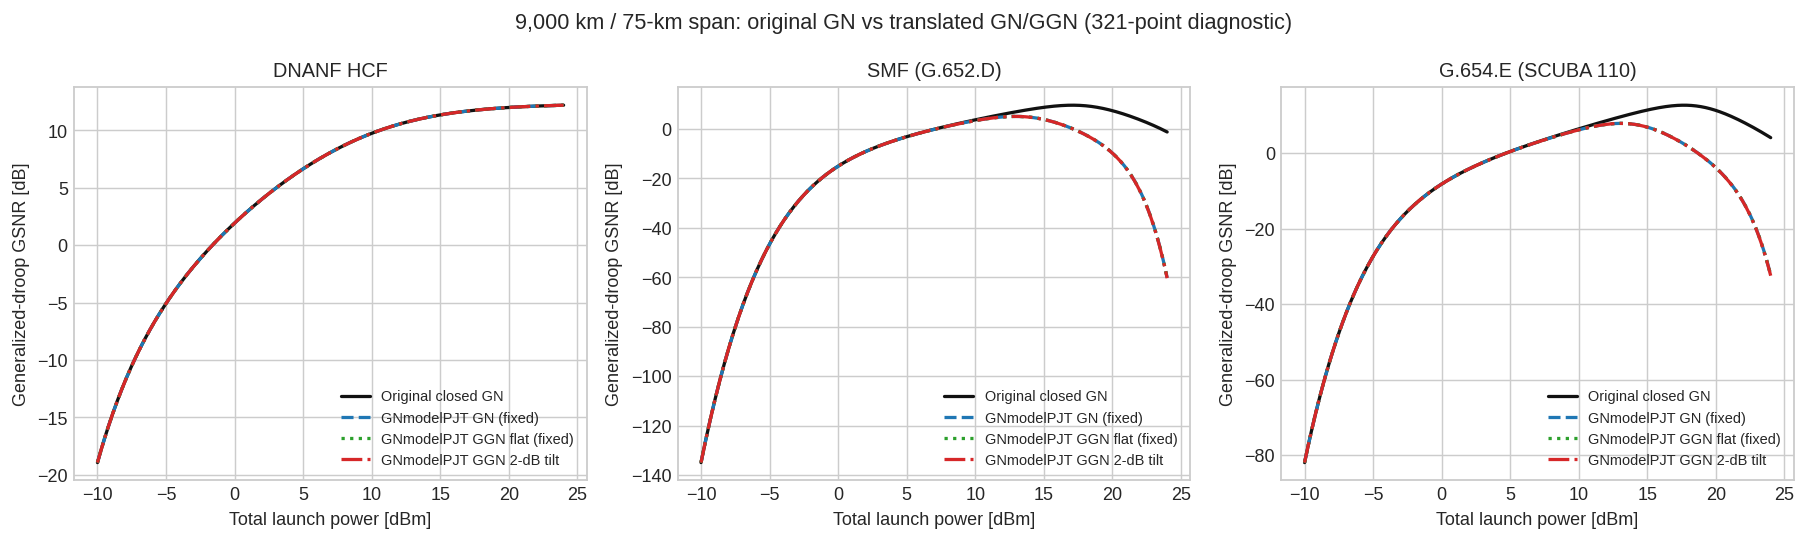

In [28]:
pgrid_dbm = np.linspace(-10, 24, 401)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
styles = {
    "Original closed GN": ("#111111", "-"),
    "GNmodelPJT GN (fixed)": ("#1f77b4", "--"),
    "GNmodelPJT GGN flat (fixed)": ("#2ca02c", ":"),
    "GNmodelPJT GGN 2-dB tilt": ("#d62728", "-."),
}
for ax, (key, fibre) in zip(axes, FIBRES.items()):
    for name, eta in model_alpha[key].items():
        y = lin_to_db(generalized_droop_gsnr_with_alpha(
            dbm_to_w(pgrid_dbm), TOTAL_LENGTH_KM, NOMINAL_SPAN_KM, fibre, eta))
        ax.plot(pgrid_dbm, y, color=styles[name][0], ls=styles[name][1], label=name)
    ax.set_title(fibre.label)
    ax.set_xlabel("Total launch power [dBm]")
    ax.set_ylabel("Generalized-droop GSNR [dB]")
    ax.legend()
fig.suptitle("9,000 km / 75-km span: original GN vs translated GN/GGN (321-point diagnostic)")
fig.tight_layout()
plt.show()

## 4. 논문 Figure 1·2 조건과 폐형식 App.EGN-2

논문 입력:

- 32 GBaud, roll-off 0.05, spacing 33.6 GHz, 100-km span, noiseless
- Figure 1: 3 PM-QPSK channels
- Figure 2: 15 PM-QPSK channels
- SMF $(\alpha,D,\gamma)=(0.22,16.7,1.3)$
- NZDSF $(0.22,3.8,1.5)$
- LS $(0.22,-1.8,2.2)$, 단위 dB/km, ps/nm/km, 1/W/km
- QPSK modulation factor $\Phi=1$

논문의 Eq. (1), (3)을 center CUT의 적분 NLI 계수로 변환하면

$$\eta_{EGN2}\approx\eta_{GN}-\frac{80}{81}\frac{\Phi\gamma^2L_{eff}^2N_s}{R_s\Delta f\pi|\beta_2|L_s}
\left[H_{(N_{ch}-1)/2}+\frac{\Delta f}{R_s}\right].$$

원 코드의 $\eta_{GN}=N_s\eta_{span}$은 완전 선형 누적이므로, 저분산/소채널에서 논문 GN의 coherent accumulation을 재현하지 못한다. 이 때문에 Eq. (3)을 단순 차감한 결과는 LS 3-channel에서 특히 보수적으로 실패할 수 있으며, 그 실패도 숨기지 않고 표시한다.

In [29]:
@dataclass(frozen=True)
class PaperFibre:
    name: str
    alpha_db_km: float
    D_ps_nm_km: float
    gamma_w_km: float

PAPER_FIBRES = {
    "SMF": PaperFibre("SMF", 0.22, 16.7, 1.3),
    "NZDSF": PaperFibre("NZDSF", 0.22, 3.8, 1.5),
    "LS": PaperFibre("LS", 0.22, -1.8, 2.2),
}
PAPER_NS = np.array([1, 2, 5, 10, 20, 50])

def closed_gn_eta_total(n_ch, n_span, pf, span_km=100, rs_hz=32e9,
                        spacing_hz=33.6e9, wavelength_nm=1550):
    alpha_p = pf.alpha_db_km/4.343
    beta2_s2_km = abs(beta2_ps2_km_from_D(pf.D_ps_nm_km, wavelength_nm))*1e-24
    leff = (1-np.exp(-alpha_p*span_km))/alpha_p
    leff_inf = 1/alpha_p
    arg = (np.pi**2/2*beta2_s2_km*leff_inf*rs_hz**2
           * n_ch**(2*rs_hz/spacing_hz))
    eta_span = ((8/27)*pf.gamma_w_km**2*leff**2*np.arcsinh(arg) /
                (np.pi*beta2_s2_km*leff_inf*rs_hz**2))
    return n_span*eta_span

def harmonic_number(n):
    return float(np.sum(1/np.arange(1, n+1))) if n else 0.0

def paper_egn2_correction(n_ch, n_span, pf, phi=1.0, span_km=100,
                          rs_thz=0.032, spacing_thz=0.0336):
    alpha_p = pf.alpha_db_km/4.343
    leff = (1-np.exp(-alpha_p*span_km))/alpha_p
    beta2 = abs(beta2_ps2_km_from_D(pf.D_ps_nm_km))
    bracket = harmonic_number((n_ch-1)//2)+spacing_thz/rs_thz
    return ((80/81)*phi*pf.gamma_w_km**2*leff**2*n_span /
            (rs_thz*spacing_thz*np.pi*beta2*span_km)*bracket)

# Digitized from the provided PDF at Nspan=[1,2,5,10,20,50].
PAPER_FIG12 = {
    (3,"SMF"): {"GN":[26.92,30.08,34.42,37.68,41.07,45.15], "EGN":[22.31,26.72,32.29,35.68,39.34,43.77]},
    (15,"SMF"): {"GN":[29.78,32.82,37.04,40.16,43.34,47.32], "EGN":[24.52,28.91,34.56,38.11,41.56,45.98]},
    (3,"NZDSF"): {"GN":[32.20,35.53,40.13,43.52,46.97,51.28], "EGN":[28.42,32.07,37.30,40.86,44.57,49.31]},
    (15,"NZDSF"): {"GN":[36.28,39.38,43.64,46.77,50.03,54.11], "EGN":[32.46,35.94,40.94,44.45,47.94,52.32]},
    (3,"LS"): {"GN":[37.06,40.53,45.39,48.86,52.47,56.93], "EGN":[33.72,37.15,41.92,45.66,49.44,54.30]},
    (15,"LS"): {"GN":[42.17,45.28,49.60,52.81,56.13,60.15], "EGN":[39.22,42.37,46.89,50.40,53.82,58.00]},
}

paper_parameter_table = pd.DataFrame([
    ("Rs", 32, "GBaud"), ("roll-off", 0.05, ""),
    ("spacing", 33.6, "GHz"), ("span", 100, "km"),
    ("Nch Fig.1", 3, ""), ("Nch Fig.2", 15, ""),
    ("launch", -3, "dBm/ch; eta is power-normalized"),
], columns=["Paper input", "Value", "Unit/note"])
display(paper_parameter_table)

,Paper input,Value,Unit/note
0,Rs,32.00,GBaud
1,roll-off,0.05,
2,spacing,33.60,GHz
3,span,100.00,km
4,Nch Fig.1,3.00,
5,Nch Fig.2,15.00,
6,launch,-3.00,dBm/ch; eta is power-normalized


In [30]:
fig12_rows = []
paper_modelpj_eta_span = {}

for nch in (3, 15):
    for name, pf in PAPER_FIBRES.items():
        tmp_fibre = FibreParameters(name, name, pf.alpha_db_km, pf.D_ps_nm_km, pf.gamma_w_km)
        # Stable single-span Cartesian integral; total is the repository-intended incoherent Ns accumulation.
        eta_num_span = eta_from_psd_function(
            gnli_psd_cartesian_single_span, tmp_fibre, 100, nch,
            0.032, 0.0336, rolloff=0.05, ngrid=401, nf=5)
        paper_modelpj_eta_span[(nch, name)] = eta_num_span

        gn = np.array([closed_gn_eta_total(nch, ns, pf) for ns in PAPER_NS])
        gn_pjt = PAPER_NS*eta_num_span
        corr = np.array([paper_egn2_correction(nch, ns, pf) for ns in PAPER_NS])
        egn2 = np.maximum(gn-corr, gn*1e-8)
        ref_gn = np.array(PAPER_FIG12[(nch,name)]["GN"])
        ref_egn = np.array(PAPER_FIG12[(nch,name)]["EGN"])
        pred_gn_db = lin_to_db(gn)
        pred_pjt_db = lin_to_db(gn_pjt)
        pred_egn2_db = lin_to_db(egn2)
        for model, pred, ref in [
            ("Original closed GN vs paper GN", pred_gn_db, ref_gn),
            ("GNmodelPJT fixed vs paper GN", pred_pjt_db, ref_gn),
            ("Eq.(3) on original GN vs paper EGN", pred_egn2_db, ref_egn),
        ]:
            err = pred-ref
            fig12_rows.append({
                "Nch": nch, "Fibre": name, "Comparison": model,
                "RMSE [dB]": np.sqrt(np.mean(err**2)),
                "bias [dB]": np.mean(err),
                "max |error| [dB]": np.max(np.abs(err)),
            })

fig12_metrics = pd.DataFrame(fig12_rows)
display(fig12_metrics.round(3))

,Nch,Fibre,Comparison,RMSE [dB],bias [dB],max |error| [dB]
0,3,SMF,Original closed GN vs paper GN,0.702,-0.526,1.133
1,3,SMF,GNmodelPJT fixed vs paper GN,1.081,-0.976,1.583
2,3,SMF,Eq.(3) on original GN vs paper EGN,1.549,0.051,2.759
3,3,NZDSF,Original closed GN vs paper GN,1.161,-0.893,1.912
4,3,NZDSF,GNmodelPJT fixed vs paper GN,1.557,-1.369,2.388
5,3,NZDSF,Eq.(3) on original GN vs paper EGN,2.613,-2.236,4.134
6,3,LS,Original closed GN vs paper GN,1.703,-1.368,2.769
7,3,LS,GNmodelPJT fixed vs paper GN,2.084,-1.821,3.222
8,3,LS,Eq.(3) on original GN vs paper EGN,9.988,-9.910,11.855
9,15,SMF,Original closed GN vs paper GN,0.407,-0.341,0.595


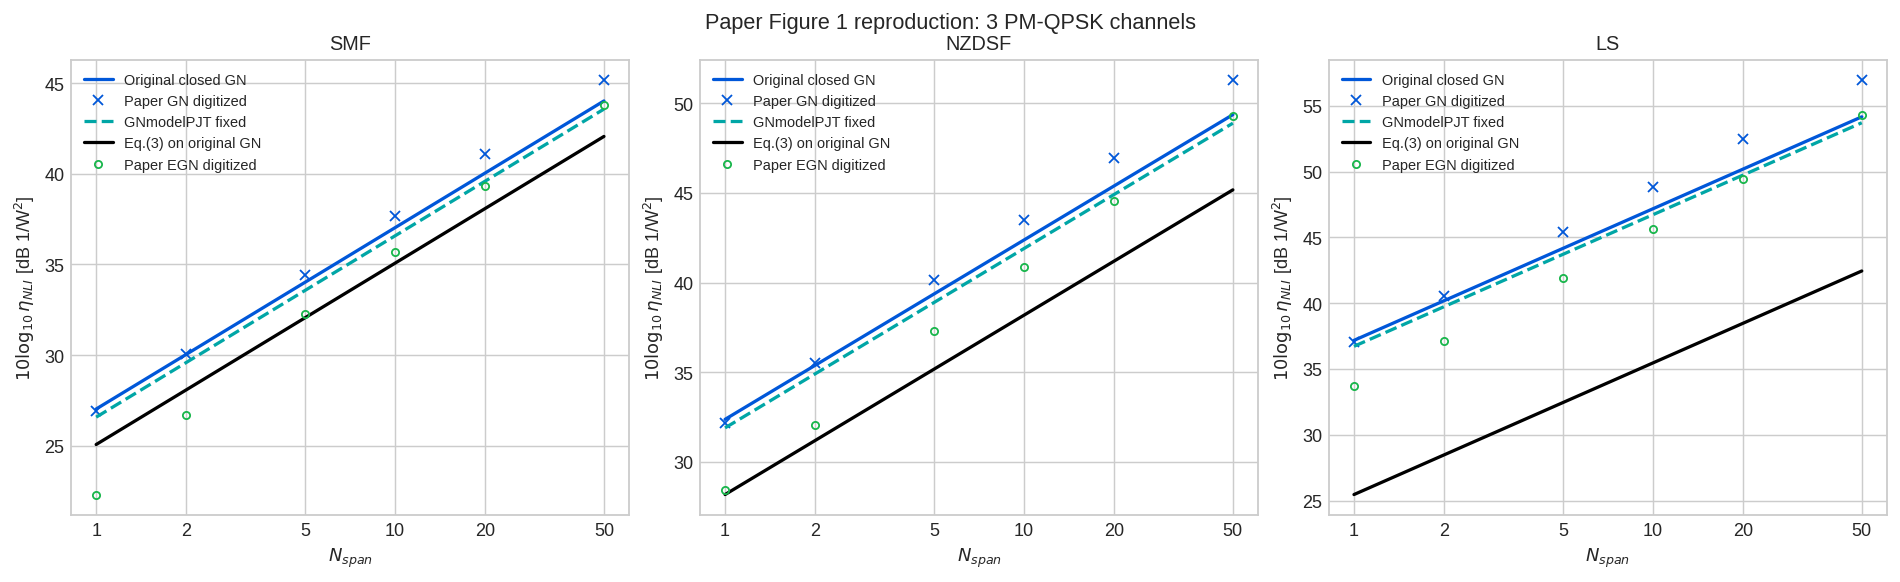

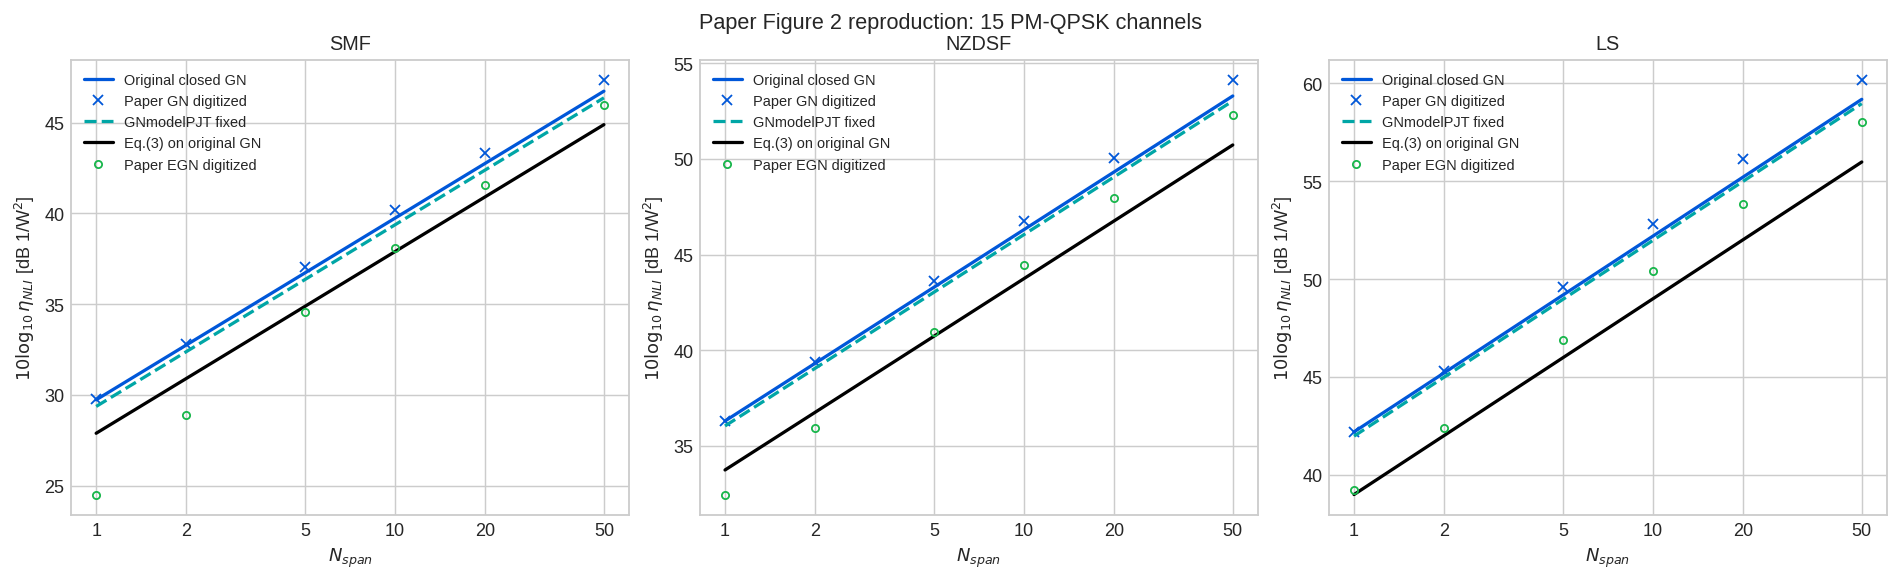

In [31]:
def plot_fig12(nch, figure_number):
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharex=True, layout="constrained")
    for ax, (name, pf) in zip(axes, PAPER_FIBRES.items()):
        gn = np.array([closed_gn_eta_total(nch, ns, pf) for ns in PAPER_NS])
        pjt = PAPER_NS*paper_modelpj_eta_span[(nch, name)]
        corr = np.array([paper_egn2_correction(nch, ns, pf) for ns in PAPER_NS])
        egn2 = np.maximum(gn-corr, gn*1e-8)
        ref = PAPER_FIG12[(nch,name)]
        ax.semilogx(PAPER_NS, lin_to_db(gn), "-", color="#0057d9", label="Original closed GN")
        ax.semilogx(PAPER_NS, ref["GN"], "x", ms=6, color="#0057d9", label="Paper GN digitized")
        ax.semilogx(PAPER_NS, lin_to_db(pjt), "--", color="#00a6a6", label="GNmodelPJT fixed")
        ax.semilogx(PAPER_NS, lin_to_db(egn2), "-", color="black", label="Eq.(3) on original GN")
        ax.semilogx(PAPER_NS, ref["EGN"], "o", ms=4, mfc="none", color="#18b64b", label="Paper EGN digitized")
        ax.set_xticks(PAPER_NS, labels=PAPER_NS)
        ax.set_title(name)
        ax.set_xlabel(r"$N_{span}$")
        ax.set_ylabel(r"$10\log_{10}\eta_{NLI}$ [dB 1/W$^2$]")
        ax.legend()
    fig.suptitle(f"Paper Figure {figure_number} reproduction: {nch} PM-QPSK channels", y=1.03)
    plt.show()

plot_fig12(3, 1)
plot_fig12(15, 2)

## 5. 논문 Figure 3: maximum system reach 재현

논문 조건:

- 15 channels, 32 GBaud, roll-off 0.05, spacing 33.6/35/40/45/50 GHz, EDFA NF=5 dB
- PM-QPSK: span 120 km, target BER $1.7\times10^{-3}$
- PM-16QAM: span 85 km, target BER $2.0\times10^{-3}$
- 두 경우 모두 FEC 임계 대비 2-dB OSNR margin
- PSCF $(0.17,20.1,0.8)$, SMF $(0.20,16.7,1.3)$, NZDSF $(0.22,3.8,1.5)$, LS $(0.22,-1.8,2.2)$

논문과 같은 per-polarization convention으로 $P_{ASE}=h\nu(F/2)R_s(G-1)$를 사용한다. 최적 launch는

$$P_{opt}=\left(\frac{P_{ASE}}{2\eta_{span}}\right)^{1/3},\qquad
N_{max}=\frac{1}{SNR_{req}(P_{ASE}/P_{opt}+\eta_{span}P_{opt}^2)}.$$

BER 근사는 QPSK $BER=\tfrac12\operatorname{erfc}(\sqrt{SNR/2})$, Gray 16QAM $BER\approx\tfrac38\operatorname{erfc}(\sqrt{SNR/10})$를 사용한다.

In [32]:
PAPER_REACH_FIBRES = {
    "PSCF": PaperFibre("PSCF", 0.17, 20.1, 0.8),
    "SMF": PaperFibre("SMF", 0.20, 16.7, 1.3),
    "NZDSF": PaperFibre("NZDSF", 0.22, 3.8, 1.5),
    "LS": PaperFibre("LS", 0.22, -1.8, 2.2),
}
PAPER_SPACING_GHZ = np.array([33.6, 35, 40, 45, 50])

# Digitized top curve (SIM marker group) and bottom GN curve from the supplied PDF.
PAPER_FIG3 = {
 "QPSK": {
  "PSCF":{"SIM":[65.30,65.85,68.66,70.11,70.99],"GN":[58.95,59.69,61.98,63.29,64.62]},
  "SMF":{"SIM":[27.79,28.37,29.46,30.21,30.78],"GN":[25.14,25.67,26.54,27.33,27.90]},
  "NZDSF":{"SIM":[12.46,12.77,13.60,14.15,14.88],"GN":[10.99,11.22,11.85,12.35,12.62]},
  "LS":{"SIM":[8.32,8.63,9.48,9.92,10.22],"GN":[7.01,7.18,7.69,7.97,8.20]}},
 "16QAM": {
  "PSCF":{"SIM":[35.59,35.59,37.85,38.80,39.63],"GN":[32.02,32.48,33.64,34.36,34.97]},
  "SMF":{"SIM":[17.41,17.72,18.91,19.38,19.80],"GN":[16.00,16.22,16.87,17.29,17.59]},
  "NZDSF":{"SIM":[8.65,8.87,9.60,10.01,10.25],"GN":[7.74,7.91,8.31,8.61,8.85]},
  "LS":{"SIM":[5.68,5.85,6.42,6.78,7.02],"GN":[4.97,5.07,5.41,5.64,5.80]}},
}

SNR_REQ = {
    "QPSK": 2*erfcinv(2*1.7e-3)**2*db_to_lin(2),
    "16QAM": 10*erfcinv((8/3)*2.0e-3)**2*db_to_lin(2),
}
SPAN_BY_MOD = {"QPSK": 120.0, "16QAM": 85.0}

def paper_reach_original(mod, pf, spacing_ghz):
    span = SPAN_BY_MOD[mod]
    eta = closed_gn_eta_total(15, 1, pf, span_km=span,
                              spacing_hz=spacing_ghz*1e9)
    gain = db_to_lin(pf.alpha_db_km*span)
    nu = C_M_PER_S/1550e-9
    pase = H_PLANCK*nu*(db_to_lin(5.0)/2)*32e9*(gain-1)
    popt = (pase/(2*eta))**(1/3)
    inv_snr_per_span = pase/popt+eta*popt**2
    return float(1/(SNR_REQ[mod]*inv_snr_per_span)), float(popt)

fig3_rows = []
fig3_predictions = {}
for mod in ("QPSK", "16QAM"):
    fig3_predictions[mod] = {}
    for name, pf in PAPER_REACH_FIBRES.items():
        pred = np.array([paper_reach_original(mod, pf, df)[0]
                         for df in PAPER_SPACING_GHZ])
        popt = np.array([paper_reach_original(mod, pf, df)[1]
                         for df in PAPER_SPACING_GHZ])
        fig3_predictions[mod][name] = pred
        ref = np.array(PAPER_FIG3[mod][name]["SIM"])
        err_db = 10*np.log10(pred/ref)
        fig3_rows.append({
            "Modulation": mod, "Fibre": name,
            "reach RMSE [dB]": np.sqrt(np.mean(err_db**2)),
            "reach bias [dB]": np.mean(err_db),
            "max |reach error| [dB]": np.max(np.abs(err_db)),
            "Popt @33.6GHz [dBm/ch]": w_to_dbm(popt[0]),
        })

fig3_metrics = pd.DataFrame(fig3_rows)
display(pd.DataFrame({"Modulation": list(SNR_REQ),
                      "Required SNR incl. margin [dB]": [lin_to_db(SNR_REQ[m]) for m in SNR_REQ]}))
display(fig3_metrics.round(3))

,Modulation,Required SNR incl. margin [dB]
0,QPSK,11.334535
1,16QAM,17.889882


,Modulation,Fibre,reach RMSE [dB],reach bias [dB],max |reach error| [dB],Popt @33.6GHz [dBm/ch]
0,QPSK,PSCF,0.072,0.068,0.104,-0.207
1,QPSK,SMF,0.056,-0.052,0.079,-0.380
2,QPSK,NZDSF,0.280,-0.272,0.365,-1.614
3,QPSK,LS,0.550,-0.541,0.647,-3.577
4,16QAM,PSCF,0.242,0.237,0.318,-2.151
5,16QAM,SMF,0.140,0.122,0.220,-2.690
6,16QAM,NZDSF,0.107,-0.068,0.153,-4.164
7,16QAM,LS,0.254,-0.233,0.337,-6.127


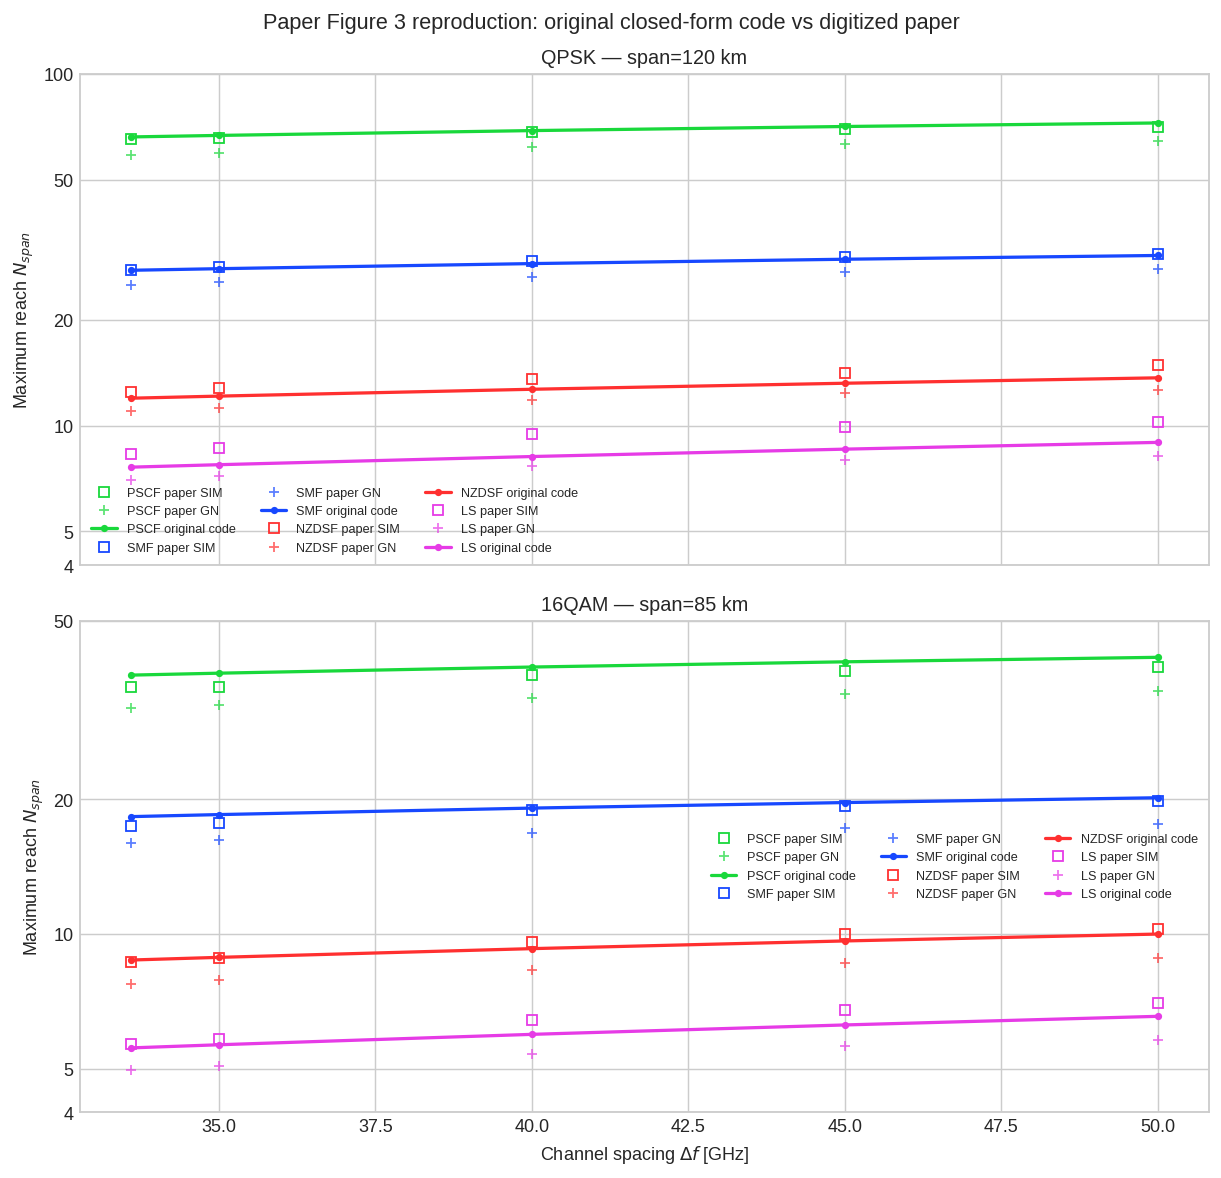

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 9.2), sharex=True)
colors = {"PSCF":"#19d83b", "SMF":"#1748ff", "NZDSF":"#ff3030", "LS":"#e63be6"}
for ax, mod in zip(axes, ("QPSK", "16QAM")):
    for name in PAPER_REACH_FIBRES:
        ax.semilogy(PAPER_SPACING_GHZ, PAPER_FIG3[mod][name]["SIM"],
                    "s", mfc="none", color=colors[name], label=f"{name} paper SIM")
        ax.semilogy(PAPER_SPACING_GHZ, PAPER_FIG3[mod][name]["GN"],
                    "+", color=colors[name], alpha=.7, label=f"{name} paper GN")
        ax.semilogy(PAPER_SPACING_GHZ, fig3_predictions[mod][name],
                    "-o", ms=3, color=colors[name], label=f"{name} original code")
    ax.set_ylabel(r"Maximum reach $N_{span}$")
    ax.set_title(f"{mod} — span={SPAN_BY_MOD[mod]:.0f} km")
    ax.set_yticks([4,5,10,20,50,100] if mod=="QPSK" else [4,5,10,20,50])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend(ncol=3, fontsize=7)
axes[-1].set_xlabel(r"Channel spacing $\Delta f$ [GHz]")
fig.suptitle("Paper Figure 3 reproduction: original closed-form code vs digitized paper")
fig.tight_layout()
plt.show()

## 6. 해석 시 주의사항

1. **Figure 1·2는 NLI 계수 검증**이다. 원 폐형식의 $N_s\eta_{span}$ 누적은 고분산·다채널에서 잘 맞지만, 저분산/소채널의 coherent accumulation을 작게 예측한다.
2. **Figure 3는 end-to-end reach 검증**이다. ASE, optimum launch, BER threshold까지 함께 작용하므로 Figure 1·2보다 더 직접적인 시스템 성능 검증이다.
3. **GGN(flat)=GN**은 성공 조건이다. 두 모델의 차이가 거의 0이면 power-profile 이식이 이론적으로 일관된 것이다.
4. **GGN과 EGN은 대체 관계가 아니다.** SRS가 없는 논문 조건에서 GGN을 추가해도 modulation-format correction은 생기지 않는다.
5. **Eq. (3) 차감은 base GN의 coherent-$N_s$ 동작을 전제로 한다.** 원 폐형식에 무조건 붙이는 방식은 LS 3채널에서 실패하므로, 논문 EGN 재현용과 해저 GDF 운용용 모델을 별도 검증해야 한다.
6. **39채널 Cartesian 적분의 절대값은 grid-sensitive하다.** 이 노트북의 321-point 값은 저장소 방식의 계산비용/수렴 문제를 드러내기 위한 진단값이다. 절대 $\eta$ 기준으로 사용할 때는 MATLAB 기본 1-GHz 수준 grid, channel-wise quadrature 또는 adaptive/hyperbolic 적분으로 수렴 검사를 먼저 해야 한다.

In [34]:
from dataclasses import replace
from matplotlib.colors import TwoSlopeNorm

JOURNAL_SEED = 20260823
JOURNAL_LENGTH_KM = 15_000
FINE_SPAN_GRID_KM = np.arange(10.0, 251.0, 1.0)
COARSE_SPAN_GRID_KM = np.arange(15.0, 251.0, 4.0)
POWER_SEARCH_DBM = np.linspace(-30.0, 30.0, 1201)
POWER_SEARCH_W = dbm_to_w(POWER_SEARCH_DBM)
FAST_POWER_DBM = np.linspace(-20.0, 24.0, 441)
FAST_POWER_W = dbm_to_w(FAST_POWER_DBM)

def eta_eo_surrogate(gain_db, total_output_power_w):
    """Replaceable 2.0--3.1% gain/output-dependent efficiency surrogate."""
    output_w = np.maximum(np.asarray(total_output_power_w, dtype=float), 1e-15)
    pout_dbm = w_to_dbm(output_w)
    gain_term = np.clip((gain_db - 7.0) / 5.0, 0.0, 1.0)
    output_term = np.clip((pout_dbm - 5.0) / 13.0, 0.0, 1.0) ** 2
    return 0.020 + 0.011 * gain_term * output_term

eta_eo_surrogate.model_label = "gain/output surrogate (2.0--3.1%)"

def make_fixed_eta_model(eta_fraction):
    if not 0.0 < eta_fraction < 1.0:
        raise ValueError("eta_fraction must lie in (0,1).")
    def fixed_eta(_gain_db, total_output_power_w):
        return np.full_like(np.asarray(total_output_power_w, dtype=float),
                            eta_fraction, dtype=float)
    fixed_eta.model_label = f"fixed eta={100*eta_fraction:.1f}%"
    fixed_eta.eta_fraction = eta_fraction
    return fixed_eta

def repeater_power_required_w(total_output_power_w, eta_eo, system=SYSTEM):
    return (2.0 * system.fibre_pairs * np.asarray(total_output_power_w)
            / ((1.0-system.circuit_fraction)*eta_eo))

def repeater_power_supplied_w(total_length_km, n_repeaters, system=SYSTEM):
    return (system.pfe_voltage_v**2
            / (4.0*system.conductor_resistance_ohm_per_km
               * total_length_km*n_repeaters))

def generalized_droop_extended(total_launch_power_w, total_length_km,
                               nominal_span_km, fibre, system=SYSTEM,
                               alpha_nli=None, extra_span_loss_db=0.0):
    """GDF GSNR with optional discrete splice/FIFO loss per span."""
    ps = np.asarray(total_launch_power_w, dtype=float)
    nrep, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    pch = ps/system.n_channels
    nu = C_NM_PER_S/system.wavelength_nm
    total_span_loss_db = fibre.attenuation_db_per_km*actual_span_km + extra_span_loss_db
    span_gain = db_to_lin(total_span_loss_db)
    pase = (H_PLANCK*nu*db_to_lin(system.noise_figure_db)
            * system.symbol_rate_hz*(span_gain-1.0))
    chi_a = 1.0/(1.0+pase/pch)
    if alpha_nli is None:
        alpha_nli = gn_alpha_nli_original(actual_span_km, fibre, system)
    chi_r = 1.0/(1.0+alpha_nli*pch**2
                 + fibre.imi_linear_per_km*actual_span_km)
    exponent = nrep*(-np.log(chi_a)-np.log(chi_r))
    return 1.0/np.expm1(np.minimum(exponent, 700.0))

def optimize_operating_point_journal(total_length_km, nominal_span_km, fibre,
                                     system=SYSTEM, eta_model=eta_eo_surrogate,
                                     power_search_w=POWER_SEARCH_W,
                                     extra_span_loss_db=0.0):
    power_search_w = np.asarray(power_search_w, dtype=float)
    nrep, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    alpha_nli = gn_alpha_nli_original(actual_span_km, fibre, system)
    curve = generalized_droop_extended(
        power_search_w, total_length_km, nominal_span_km, fibre, system,
        alpha_nli=alpha_nli, extra_span_loss_db=extra_span_loss_db)
    p_nl_w = power_search_w[int(np.nanargmax(curve))]
    p_backoff_w = p_nl_w/db_to_lin(system.nl_backoff_db)
    p_hardware_w = dbm_to_w(system.launch_power_limit_dbm)

    gain_db = fibre.attenuation_db_per_km*actual_span_km + extra_span_loss_db
    eta_candidates = eta_model(gain_db, power_search_w)
    required = repeater_power_required_w(power_search_w, eta_candidates, system)
    supplied = repeater_power_supplied_w(total_length_km, nrep, system)
    feasible = required <= supplied
    if not np.any(feasible):
        raise RuntimeError("No PFE-feasible launch power in search grid.")
    p_pfe_w = power_search_w[np.flatnonzero(feasible)[-1]]
    limits = {"PFE": p_pfe_w, "NL-2 dB": p_backoff_w, "18 dBm": p_hardware_w}
    active = min(limits, key=limits.get)
    p_used_w = limits[active]
    eta_used = float(np.asarray(eta_model(gain_db, p_used_w)))
    required_used = float(repeater_power_required_w(p_used_w, eta_used, system))
    gsnr_db = float(lin_to_db(generalized_droop_extended(
        np.array([p_used_w]), total_length_km, nominal_span_km, fibre, system,
        alpha_nli=alpha_nli, extra_span_loss_db=extra_span_loss_db)[0]))
    return {
        "fibre": fibre.key, "label": fibre.label,
        "total_length_km": float(total_length_km),
        "nominal_span_km": float(nominal_span_km),
        "actual_span_km": float(actual_span_km),
        "n_repeaters": int(nrep),
        "optimal_gsnr_db": gsnr_db,
        "p_used_dbm": float(w_to_dbm(p_used_w)),
        "p_nl_dbm": float(w_to_dbm(p_nl_w)),
        "p_pfe_dbm": float(w_to_dbm(p_pfe_w)),
        "active_constraint": active,
        "eta_eo": eta_used,
        "p_rep_required_w": required_used,
        "p_rep_supplied_w": float(supplied),
        "extra_span_loss_db": float(extra_span_loss_db),
    }

def optimize_span_journal(total_length_km, fibre, system=SYSTEM,
                          eta_model=eta_eo_surrogate,
                          span_grid_km=FINE_SPAN_GRID_KM,
                          power_search_w=POWER_SEARCH_W,
                          extra_span_loss_db=0.0, return_candidates=False):
    rows = [optimize_operating_point_journal(
        total_length_km, span, fibre, system=system, eta_model=eta_model,
        power_search_w=power_search_w, extra_span_loss_db=extra_span_loss_db)
        for span in span_grid_km]
    best = max(rows, key=lambda r: r["optimal_gsnr_db"])
    return (best, pd.DataFrame(rows)) if return_candidates else best

print("Journal extension setup: PASS")


Journal extension setup: PASS


## 7. Frequency-grid 수렴성 및 계산시간

동일 75-km span, 39채널 조건에서 Cartesian GN 적분 grid를 81–1281 points로 증가시킨다. 각 광섬유의 1281-point 결과를 내부 수치 기준으로 두고 NLI 계수 오차와 실행시간을 함께 표시한다. 이 결과는 grid 독립성을 확인하는 절차이며, 1281-point 값 자체를 실험 기준값으로 간주하지 않는다.


,Fibre,grid_points,eta_1_per_W2,eta_db,runtime_s,reference_eta_db,error_vs_1281_db
0,HCF,81,0.00529,-22.76672,0.00789,-33.59846,10.83174
1,HCF,161,0.00274,-25.62695,0.01482,-33.59846,7.97151
2,HCF,321,0.00142,-28.47863,0.06556,-33.59846,5.11983
3,HCF,641,0.00078,-31.06660,0.30043,-33.59846,2.53186
4,HCF,1281,0.00044,-33.59846,1.84707,-33.59846,0.00000
5,SMF,81,10741.58091,40.31068,0.00905,28.71627,11.59441
6,SMF,161,5550.81002,37.44356,0.02545,28.71627,8.72730
7,SMF,321,2826.40569,34.51234,0.10144,28.71627,5.79608
8,SMF,641,1448.41153,31.60892,0.38799,28.71627,2.89265
9,SMF,1281,744.09230,28.71627,1.83322,28.71627,0.00000


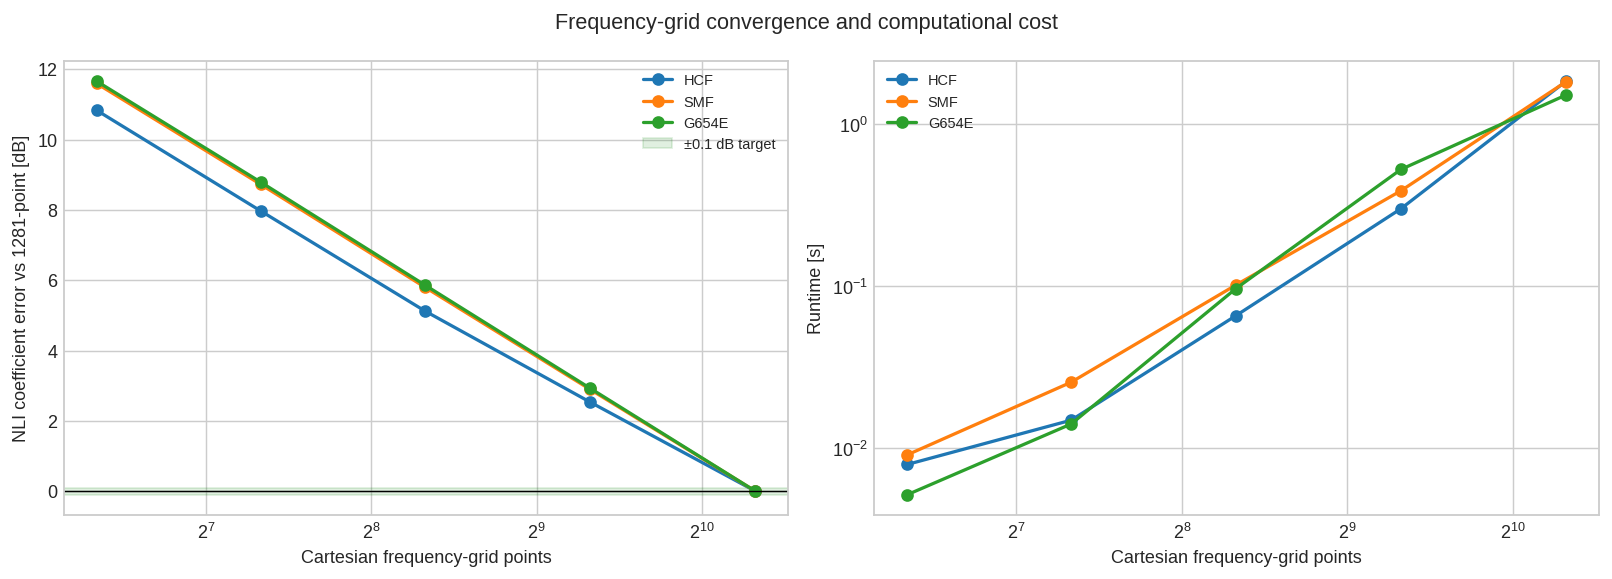

Maximum |321-point - 1281-point| = 5.857 dB
Grid convergence cell: PASS


In [35]:
GRID_LEVELS = np.array([81, 161, 321, 641, 1281])
GRID_TEST_SPAN_KM = 75.0
grid_rows = []

for key, fibre in FIBRES.items():
    for ngrid in GRID_LEVELS:
        t0 = time.perf_counter()
        eta = eta_from_psd_function(
            gnli_psd_cartesian_single_span, fibre, GRID_TEST_SPAN_KM,
            39, RS_THz, DF_THz, ngrid=int(ngrid), nf=3)
        grid_rows.append({
            "Fibre": key, "grid_points": int(ngrid),
            "eta_1_per_W2": eta,
            "eta_db": float(lin_to_db(eta)),
            "runtime_s": time.perf_counter()-t0,
        })

GRID_CONVERGENCE = pd.DataFrame(grid_rows)
GRID_CONVERGENCE["reference_eta_db"] = GRID_CONVERGENCE.groupby(
    "Fibre")["eta_db"].transform("last")
GRID_CONVERGENCE["error_vs_1281_db"] = (
    GRID_CONVERGENCE["eta_db"]-GRID_CONVERGENCE["reference_eta_db"])
display(GRID_CONVERGENCE.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for key in FIBRES:
    d = GRID_CONVERGENCE[GRID_CONVERGENCE["Fibre"] == key]
    axes[0].plot(d["grid_points"], d["error_vs_1281_db"],
                 marker="o", label=key)
    axes[1].plot(d["grid_points"], d["runtime_s"],
                 marker="o", label=key)
axes[0].axhspan(-0.1, 0.1, color="green", alpha=0.12, label="±0.1 dB target")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("Cartesian frequency-grid points")
axes[0].set_ylabel("NLI coefficient error vs 1281-point [dB]")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Cartesian frequency-grid points")
axes[1].set_ylabel("Runtime [s]")
for ax in axes:
    ax.legend()
fig.suptitle("Frequency-grid convergence and computational cost")
fig.tight_layout()
plt.show()

grid_321_abs = GRID_CONVERGENCE.query("grid_points == 321")[
    "error_vs_1281_db"].abs().max()
print(f"Maximum |321-point - 1281-point| = {grid_321_abs:.3f} dB")
print("Grid convergence cell: PASS")


,Fibre,points_per_channel,total_active_points,eta_db,runtime_s,reference_eta_db,error_vs_32ppc_db
0,HCF,2,78,-39.60702,0.00832,-36.09893,-3.50810
1,HCF,4,156,-38.17802,0.02174,-36.09893,-2.07910
2,HCF,8,312,-37.33870,0.10484,-36.09893,-1.23977
3,HCF,16,624,-36.63618,0.44286,-36.09893,-0.53725
4,HCF,32,1248,-36.09893,2.31323,-36.09893,0.00000
5,SMF,2,78,17.87861,0.00680,20.93438,-3.05577
6,SMF,4,156,17.78632,0.02109,20.93438,-3.14807
7,SMF,8,312,19.37123,0.10047,20.93438,-1.56315
8,SMF,16,624,20.27370,0.43913,20.93438,-0.66069
9,SMF,32,1248,20.93438,2.25468,20.93438,0.00000


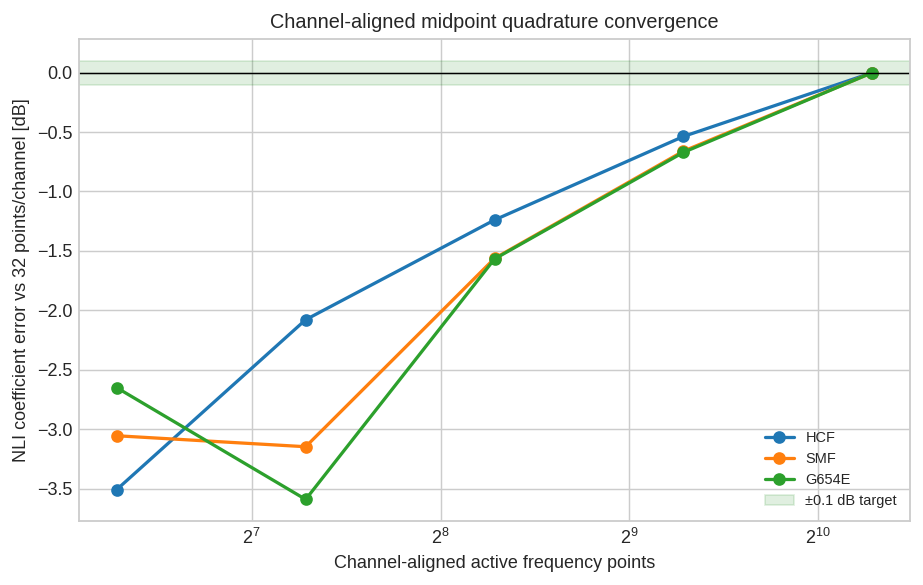

Legacy 321-point max error = 5.857 dB
Aligned 8-point/channel max error = 1.568 dB
Channel-aligned 8-point/channel convergence verdict: NOT CONVERGED — use refined/hyperbolic closed-form reference
Channel-aligned refinement diagnostic: PASS


In [36]:
def gn_eta_channel_aligned_midpoint(fibre, span_km, n_ch, rs_thz,
                                      spacing_thz, points_per_channel=8,
                                      cut_points=5):
    """Midpoint quadrature whose samples are aligned to each WDM channel."""
    centres = spacing_thz*np.arange(-(n_ch//2), n_ch//2+1)
    offsets = ((np.arange(points_per_channel)+0.5)/points_per_channel-0.5)*rs_thz
    grid = (centres[:, None]+offsets[None, :]).ravel()
    df = rs_thz/points_per_channel
    g = rectangular_wdm_psd(grid, n_ch, rs_thz, spacing_thz)
    f1, f2 = grid[:, None], grid[None, :]
    beta2 = beta2_ps2_km_from_D(fibre.dispersion_ps_nm_km)
    alpha_p = fibre.attenuation_db_per_km/4.343
    cut_offsets = ((np.arange(cut_points)+0.5)/cut_points-0.5)*rs_thz
    dcut = rs_thz/cut_points
    psd_values = []
    for f_eval in cut_offsets:
        f3 = f1+f2-f_eval
        g3 = rectangular_wdm_psd(f3, n_ch, rs_thz, spacing_thz)
        mismatch = 4*np.pi**2*beta2*(f1-f_eval)*(f2-f_eval)
        link = ((1-np.exp((-alpha_p+1j*mismatch)*span_km))
                /(alpha_p-1j*mismatch))
        integral = np.sum(
            np.abs(link)**2*g[:, None]*g[None, :]*g3)*df**2
        psd_values.append(
            (16/27)*fibre.gamma_per_w_km**2*integral*1e-12)
    return float(np.sum(psd_values)*dcut*1e12)

CHANNEL_POINTS = np.array([2, 4, 8, 16, 32])
aligned_rows = []
for key, fibre in FIBRES.items():
    for ppc in CHANNEL_POINTS:
        t0 = time.perf_counter()
        eta = gn_eta_channel_aligned_midpoint(
            fibre, GRID_TEST_SPAN_KM, 39, RS_THz, DF_THz,
            points_per_channel=int(ppc), cut_points=5)
        aligned_rows.append({
            "Fibre": key,
            "points_per_channel": int(ppc),
            "total_active_points": int(39*ppc),
            "eta_db": float(lin_to_db(eta)),
            "runtime_s": time.perf_counter()-t0,
        })

ALIGNED_GRID_CONVERGENCE = pd.DataFrame(aligned_rows)
ALIGNED_GRID_CONVERGENCE["reference_eta_db"] = (
    ALIGNED_GRID_CONVERGENCE.groupby("Fibre")["eta_db"].transform("last"))
ALIGNED_GRID_CONVERGENCE["error_vs_32ppc_db"] = (
    ALIGNED_GRID_CONVERGENCE["eta_db"]
    - ALIGNED_GRID_CONVERGENCE["reference_eta_db"])
display(ALIGNED_GRID_CONVERGENCE.round(5))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for key in FIBRES:
    d = ALIGNED_GRID_CONVERGENCE[
        ALIGNED_GRID_CONVERGENCE["Fibre"]==key]
    ax.plot(d["total_active_points"], d["error_vs_32ppc_db"],
            "o-", label=key)
ax.axhspan(-0.1, 0.1, color="green", alpha=0.12,
           label="±0.1 dB target")
ax.axhline(0, color="black", lw=0.8)
ax.set_xscale("log", base=2)
ax.set_xlabel("Channel-aligned active frequency points")
ax.set_ylabel("NLI coefficient error vs 32 points/channel [dB]")
ax.set_title("Channel-aligned midpoint quadrature convergence")
ax.legend()
fig.tight_layout()
plt.show()

grid_aligned_8ppc_abs = ALIGNED_GRID_CONVERGENCE.query(
    "points_per_channel == 8")["error_vs_32ppc_db"].abs().max()
CHANNEL_ALIGNED_CONVERGED = bool(grid_aligned_8ppc_abs <= 0.1)
print(f"Legacy 321-point max error = {grid_321_abs:.3f} dB")
print(f"Aligned 8-point/channel max error = "
      f"{grid_aligned_8ppc_abs:.3f} dB")
print("Channel-aligned 8-point/channel convergence verdict: "
      + ("PASS" if CHANNEL_ALIGNED_CONVERGED else
         "NOT CONVERGED — use refined/hyperbolic closed-form reference"))
print("Channel-aligned refinement diagnostic: PASS")


## 8. 대표 waveform-level scalar SSFM 검산

SMF, 32 GBaud, 3채널, 37.5 GHz spacing, 단일 75-km span을 대상으로 실제 QPSK waveform을 생성하고 symmetric split-step Fourier method로 전달한다. 수신단에서 선형 기준 파형을 제거해 CUT 대역의 비선형 왜곡전력을 구한다.

- 이 셀은 Cartesian GN과 독립적인 NLSE propagation sanity check다.
- PM 효과, DSP 구현손실, PMD, laser phase noise, 다중-span ASE–NLI 상호작용은 포함하지 않는다.
- QPSK SSFM과 Gaussian-statistics GN의 차이는 EGN 성분을 포함하므로 완전 일치를 요구하지 않는다.


,Pch_dBm,Pch_W,PNLI_W,eta_SSFM_1_per_W2,eta_GN_1_per_W2,SSFM_minus_GN_dB
0,-6.0,0.000251,0.000000,244.164680,465.993227,-2.806968
1,-3.0,0.000501,0.000000,244.218214,465.993227,-2.806016
2,0.0,0.001000,0.000000,244.261651,465.993227,-2.805243
3,3.0,0.001995,0.000002,244.096338,465.993227,-2.808183


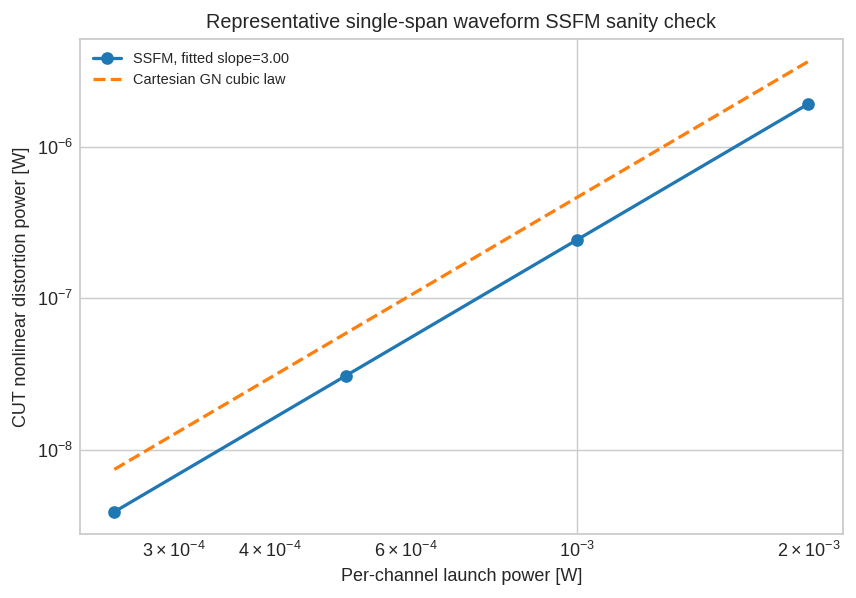

SSFM cubic slope = 3.000; sanity check: PASS


In [37]:
def make_nyquist_wdm(n_symbols=2048, sps=8, rs_hz=32e9,
                     spacing_hz=37.5e9, n_channels=3, seed=JOURNAL_SEED):
    rng = np.random.default_rng(seed)
    n = n_symbols*sps
    fs = rs_hz*sps
    t = np.arange(n)/fs
    freq = np.fft.fftfreq(n, d=1/fs)
    base_filter = (np.abs(freq) <= rs_hz/2).astype(float)
    centres = spacing_hz*np.arange(-(n_channels//2), n_channels//2+1)
    channels = []
    for _ in centres:
        symbols = ((2*rng.integers(0, 2, n_symbols)-1)
                   + 1j*(2*rng.integers(0, 2, n_symbols)-1))/np.sqrt(2)
        impulses = np.zeros(n, dtype=complex)
        impulses[::sps] = symbols
        pulse = np.fft.ifft(np.fft.fft(impulses)*base_filter)
        pulse /= np.sqrt(np.mean(np.abs(pulse)**2))
        channels.append(pulse)
    return t, freq, centres, np.asarray(channels), base_filter, fs

def ssfm_single_span(field, freq_hz, fibre, span_km, n_steps=40):
    n_steps = int(n_steps)
    length_m = span_km*1e3
    dz = length_m/n_steps
    omega = 2*np.pi*freq_hz
    beta2_s2_m = beta2_ps2_km_from_D(
        fibre.dispersion_ps_nm_km)*1e-24/1e3
    alpha_power_m = fibre.attenuation_db_per_km/4.343/1e3
    gamma_w_m = fibre.gamma_per_w_km/1e3
    half_linear = np.exp(
        -alpha_power_m*dz/4 + 1j*beta2_s2_m*omega**2*dz/4)
    a = np.asarray(field, dtype=complex).copy()
    for _ in range(n_steps):
        a = np.fft.ifft(np.fft.fft(a)*half_linear)
        a *= np.exp(1j*gamma_w_m*np.abs(a)**2*dz)
        a = np.fft.ifft(np.fft.fft(a)*half_linear)
    # Ideal lumped EDFA gain restoring span power.
    a *= np.exp(alpha_power_m*length_m/2)
    return a

def ssfm_nli_eta_smoke_test(pch_dbm_values=(-6.0, -3.0, 0.0, 3.0),
                            span_km=75.0):
    rs_hz, spacing_hz, nch = 32e9, 37.5e9, 3
    t, freq, centres, channels, cut_filter, fs = make_nyquist_wdm(
        rs_hz=rs_hz, spacing_hz=spacing_hz, n_channels=nch)
    fibre = FIBRES["SMF"]
    omega = 2*np.pi*freq
    beta2_s2_m = beta2_ps2_km_from_D(
        fibre.dispersion_ps_nm_km)*1e-24/1e3
    inverse_dispersion = np.exp(
        -1j*beta2_s2_m*omega**2*(span_km*1e3)/2)
    rows = []
    for p_dbm in pch_dbm_values:
        pch_w = float(dbm_to_w(p_dbm))
        field = np.zeros_like(channels[0])
        for centre, waveform in zip(centres, channels):
            field += np.sqrt(pch_w)*waveform*np.exp(1j*2*np.pi*centre*t)
        out_nl = ssfm_single_span(field, freq, fibre, span_km, n_steps=40)
        # gamma=0 linear reference uses the same numerical grid.
        linear_fibre = replace(fibre, gamma_per_w_km=0.0)
        out_lin = ssfm_single_span(field, freq, linear_fibre, span_km, n_steps=40)
        out_nl = np.fft.ifft(np.fft.fft(out_nl)*inverse_dispersion)
        out_lin = np.fft.ifft(np.fft.fft(out_lin)*inverse_dispersion)
        cut_nl = np.fft.ifft(np.fft.fft(out_nl)*cut_filter)
        cut_lin = np.fft.ifft(np.fft.fft(out_lin)*cut_filter)
        gain = np.vdot(cut_lin, cut_nl)/np.vdot(cut_lin, cut_lin)
        residual = cut_nl-gain*cut_lin
        pnli_w = float(np.mean(np.abs(residual)**2))
        rows.append({
            "Pch_dBm": p_dbm, "Pch_W": pch_w, "PNLI_W": pnli_w,
            "eta_SSFM_1_per_W2": pnli_w/pch_w**3,
        })
    out = pd.DataFrame(rows)
    slope = float(np.polyfit(np.log10(out["Pch_W"]),
                             np.log10(out["PNLI_W"]), 1)[0])
    eta_ssfm = float(np.median(out["eta_SSFM_1_per_W2"]))
    eta_gn = eta_from_psd_function(
        gnli_psd_cartesian_single_span, fibre, span_km, nch,
        rs_hz/1e12, spacing_hz/1e12, ngrid=641, nf=5)
    out["eta_GN_1_per_W2"] = eta_gn
    out["SSFM_minus_GN_dB"] = lin_to_db(
        out["eta_SSFM_1_per_W2"]/eta_gn)
    return out, slope, eta_ssfm, eta_gn

SSFM_VALIDATION, SSFM_CUBIC_SLOPE, ETA_SSFM, ETA_GN_SSFMCFG = (
    ssfm_nli_eta_smoke_test())
display(SSFM_VALIDATION.round(6))

fig, ax = plt.subplots(figsize=(6.7, 4.7))
ax.loglog(SSFM_VALIDATION["Pch_W"], SSFM_VALIDATION["PNLI_W"],
          "o-", label=f"SSFM, fitted slope={SSFM_CUBIC_SLOPE:.2f}")
p = SSFM_VALIDATION["Pch_W"].to_numpy()
ax.loglog(p, ETA_GN_SSFMCFG*p**3, "--", label="Cartesian GN cubic law")
ax.set_xlabel("Per-channel launch power [W]")
ax.set_ylabel("CUT nonlinear distortion power [W]")
ax.set_title("Representative single-span waveform SSFM sanity check")
ax.legend()
fig.tight_layout()
plt.show()

assert np.all(np.isfinite(SSFM_VALIDATION["PNLI_W"]))
assert 2.0 < SSFM_CUBIC_SLOPE < 4.0
print(f"SSFM cubic slope = {SSFM_CUBIC_SLOPE:.3f}; sanity check: PASS")


## 9. 15,000-km PFE 제약 기준 설계

기존 논문 초안과 동일하게 12 fibre pairs, 18 kV PFE, NF 4.5 dB, 100 GBaud, 112.5 GHz spacing, 4.3 THz 대역을 적용한다. 운전출력은 PFE 상한, 비선형 최적점 대비 2 dB back-off, 18 dBm hardware 상한 중 최솟값으로 선택한다.


In [38]:
canonical_rows = []
canonical_candidates = {}
for key, fibre in FIBRES.items():
    best, candidates = optimize_span_journal(
        JOURNAL_LENGTH_KM, fibre, return_candidates=True)
    canonical_rows.append(best)
    canonical_candidates[key] = candidates

CANONICAL_RESULTS = pd.DataFrame(canonical_rows)
CANONICAL_RESULTS["repeater_reduction_vs_SMF_percent"] = (
    100*(CANONICAL_RESULTS.loc[
        CANONICAL_RESULTS["fibre"]=="SMF", "n_repeaters"].iloc[0]
         - CANONICAL_RESULTS["n_repeaters"])
    / CANONICAL_RESULTS.loc[
        CANONICAL_RESULTS["fibre"]=="SMF", "n_repeaters"].iloc[0])
display(CANONICAL_RESULTS[[
    "fibre", "optimal_gsnr_db", "nominal_span_km", "actual_span_km",
    "n_repeaters", "p_used_dbm", "eta_eo", "active_constraint",
    "repeater_reduction_vs_SMF_percent"]].round(4))

expected = {
    "HCF": {"gsnr": 8.814, "span": 154.0, "nrep": 97},
    "SMF": {"gsnr": 6.399, "span": 40.0, "nrep": 375},
    "G654E": {"gsnr": 8.198, "span": 58.0, "nrep": 258},
}
for key, target in expected.items():
    row = CANONICAL_RESULTS[CANONICAL_RESULTS["fibre"]==key].iloc[0]
    assert abs(row["optimal_gsnr_db"]-target["gsnr"]) < 0.08
    assert abs(row["nominal_span_km"]-target["span"]) <= 1.0
    assert row["n_repeaters"] == target["nrep"]
print("Canonical 15,000-km regression checks: PASS")


,fibre,optimal_gsnr_db,nominal_span_km,actual_span_km,n_repeaters,p_used_dbm,eta_eo,active_constraint,repeater_reduction_vs_SMF_percent
0,HCF,8.8137,154.0,154.6392,97,17.95,0.0300,PFE,74.1333
1,SMF,6.3990,40.0,40.0000,375,10.35,0.0201,PFE,0.0000
2,G654E,8.1977,58.0,58.1395,258,12.20,0.0212,PFE,31.2000


Canonical 15,000-km regression checks: PASS


## 10. Span–launch-power–GSNR 2차원 설계 지도

색상은 PFE와 18 dBm hardware 제약을 만족하는 GSNR이다. 흰 영역은 PFE 또는 hardware 한도를 위반한다. 검은 실선은 PFE feasible boundary, 별표는 nested optimization으로 구한 최적 운전점이다.


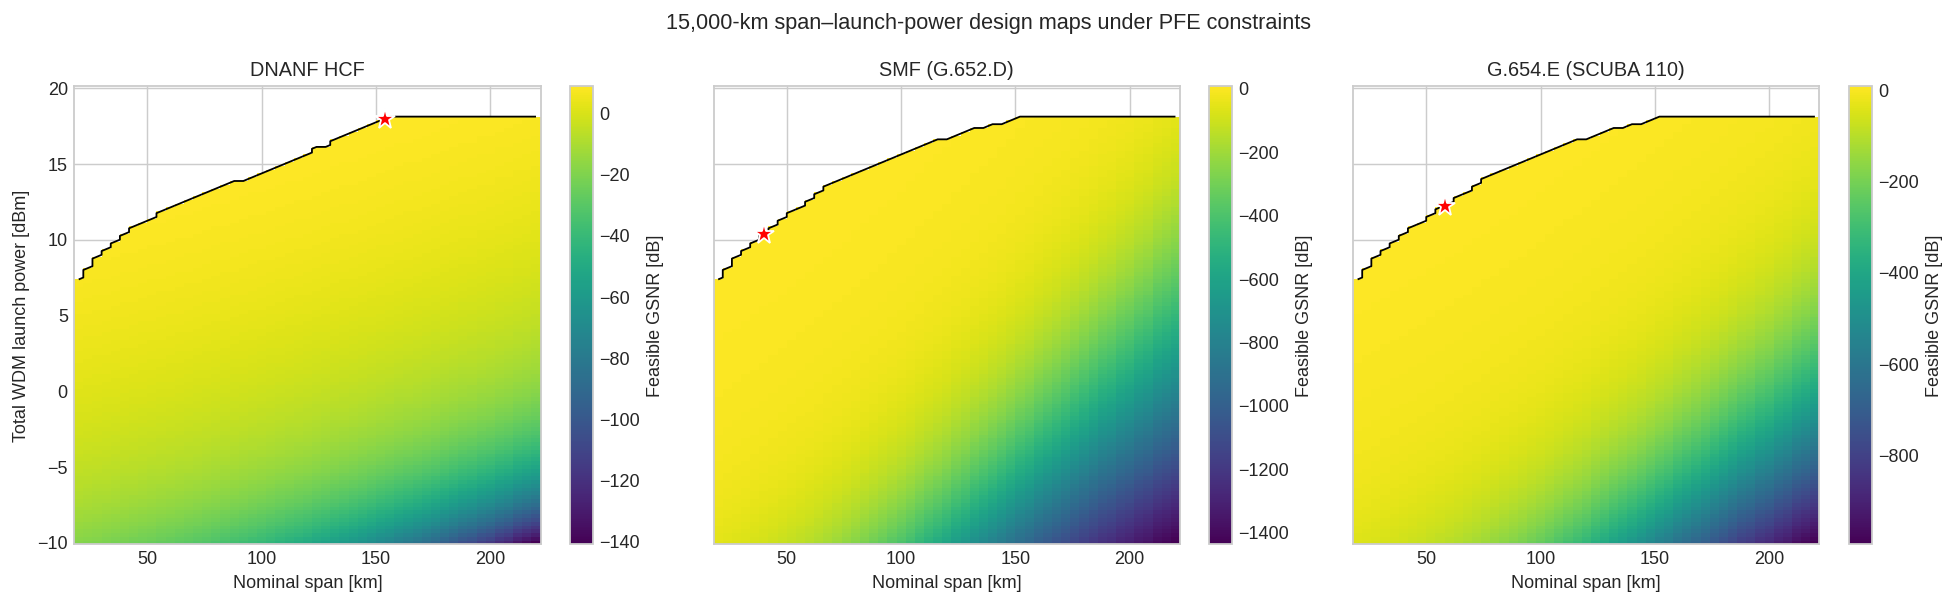

Design-map feasibility checks: PASS


In [39]:
MAP_SPAN_GRID_KM = np.arange(20.0, 221.0, 4.0)
MAP_POWER_DBM = np.linspace(-10.0, 20.0, 121)
MAP_POWER_W = dbm_to_w(MAP_POWER_DBM)

fig, axes = plt.subplots(1, 3, figsize=(15.3, 4.7), sharey=True)
DESIGN_MAPS = {}
for ax, (key, fibre) in zip(axes, FIBRES.items()):
    z = np.full((len(MAP_POWER_DBM), len(MAP_SPAN_GRID_KM)), np.nan)
    feasible_map = np.zeros_like(z, dtype=bool)
    for j, span in enumerate(MAP_SPAN_GRID_KM):
        nrep, actual = span_count_and_length(JOURNAL_LENGTH_KM, span)
        eta_nli = gn_alpha_nli_original(actual, fibre, SYSTEM)
        gsnr_db = lin_to_db(generalized_droop_extended(
            MAP_POWER_W, JOURNAL_LENGTH_KM, span, fibre,
            alpha_nli=eta_nli))
        gain_db = fibre.attenuation_db_per_km*actual
        eta = eta_eo_surrogate(gain_db, MAP_POWER_W)
        required = repeater_power_required_w(MAP_POWER_W, eta, SYSTEM)
        supplied = repeater_power_supplied_w(
            JOURNAL_LENGTH_KM, nrep, SYSTEM)
        feasible = ((required <= supplied)
                    & (MAP_POWER_DBM <= SYSTEM.launch_power_limit_dbm))
        z[:, j] = np.where(feasible, gsnr_db, np.nan)
        feasible_map[:, j] = feasible
    DESIGN_MAPS[key] = {"gsnr_db": z, "feasible": feasible_map}
    mesh = ax.pcolormesh(MAP_SPAN_GRID_KM, MAP_POWER_DBM, z,
                         shading="auto", cmap="viridis")
    ax.contour(MAP_SPAN_GRID_KM, MAP_POWER_DBM,
               feasible_map.astype(float), levels=[0.5],
               colors="black", linewidths=1.0)
    best = CANONICAL_RESULTS[CANONICAL_RESULTS["fibre"]==key].iloc[0]
    ax.plot(best["nominal_span_km"], best["p_used_dbm"],
            marker="*", ms=12, color="red", mec="white")
    ax.set_title(fibre.label)
    ax.set_xlabel("Nominal span [km]")
    fig.colorbar(mesh, ax=ax, label="Feasible GSNR [dB]")
axes[0].set_ylabel("Total WDM launch power [dBm]")
fig.suptitle("15,000-km span–launch-power design maps under PFE constraints")
fig.tight_layout()
plt.show()
print("Design-map feasibility checks: PASS")


## 11. EDFA 효율 및 PFE 전압 민감도

고정 효율 2.0%, 2.5%, 3.1%, 4.0%와 현재 gain/output-dependent surrogate를 PFE 12/15/18 kV에서 비교한다. 고정 효율 envelope는 공개되지 않은 실제 EDFA 효율표로 인한 설계 불확실성 범위를 나타내며, 절대값 검증을 뜻하지 않는다.


,fibre,pfe_voltage_kv,eta_scenario,optimal_gsnr_db,nominal_span_km,n_repeaters,p_used_dbm,active_constraint
0,HCF,12,2.0%,7.202,98.0,153,10.7,PFE
1,SMF,12,2.0%,2.337,40.0,375,6.8,PFE
2,G654E,12,2.0%,4.248,48.0,312,7.6,PFE
3,HCF,12,2.5%,7.657,94.0,159,11.5,PFE
4,SMF,12,2.5%,3.484,36.0,416,7.3,PFE
5,G654E,12,2.5%,5.362,44.0,340,8.2,PFE
6,HCF,12,3.1%,8.032,98.0,153,12.6,PFE
7,SMF,12,3.1%,4.615,38.0,394,8.5,PFE
8,G654E,12,3.1%,6.390,48.0,312,9.5,PFE
9,HCF,12,4.0%,8.417,100.0,150,13.8,PFE


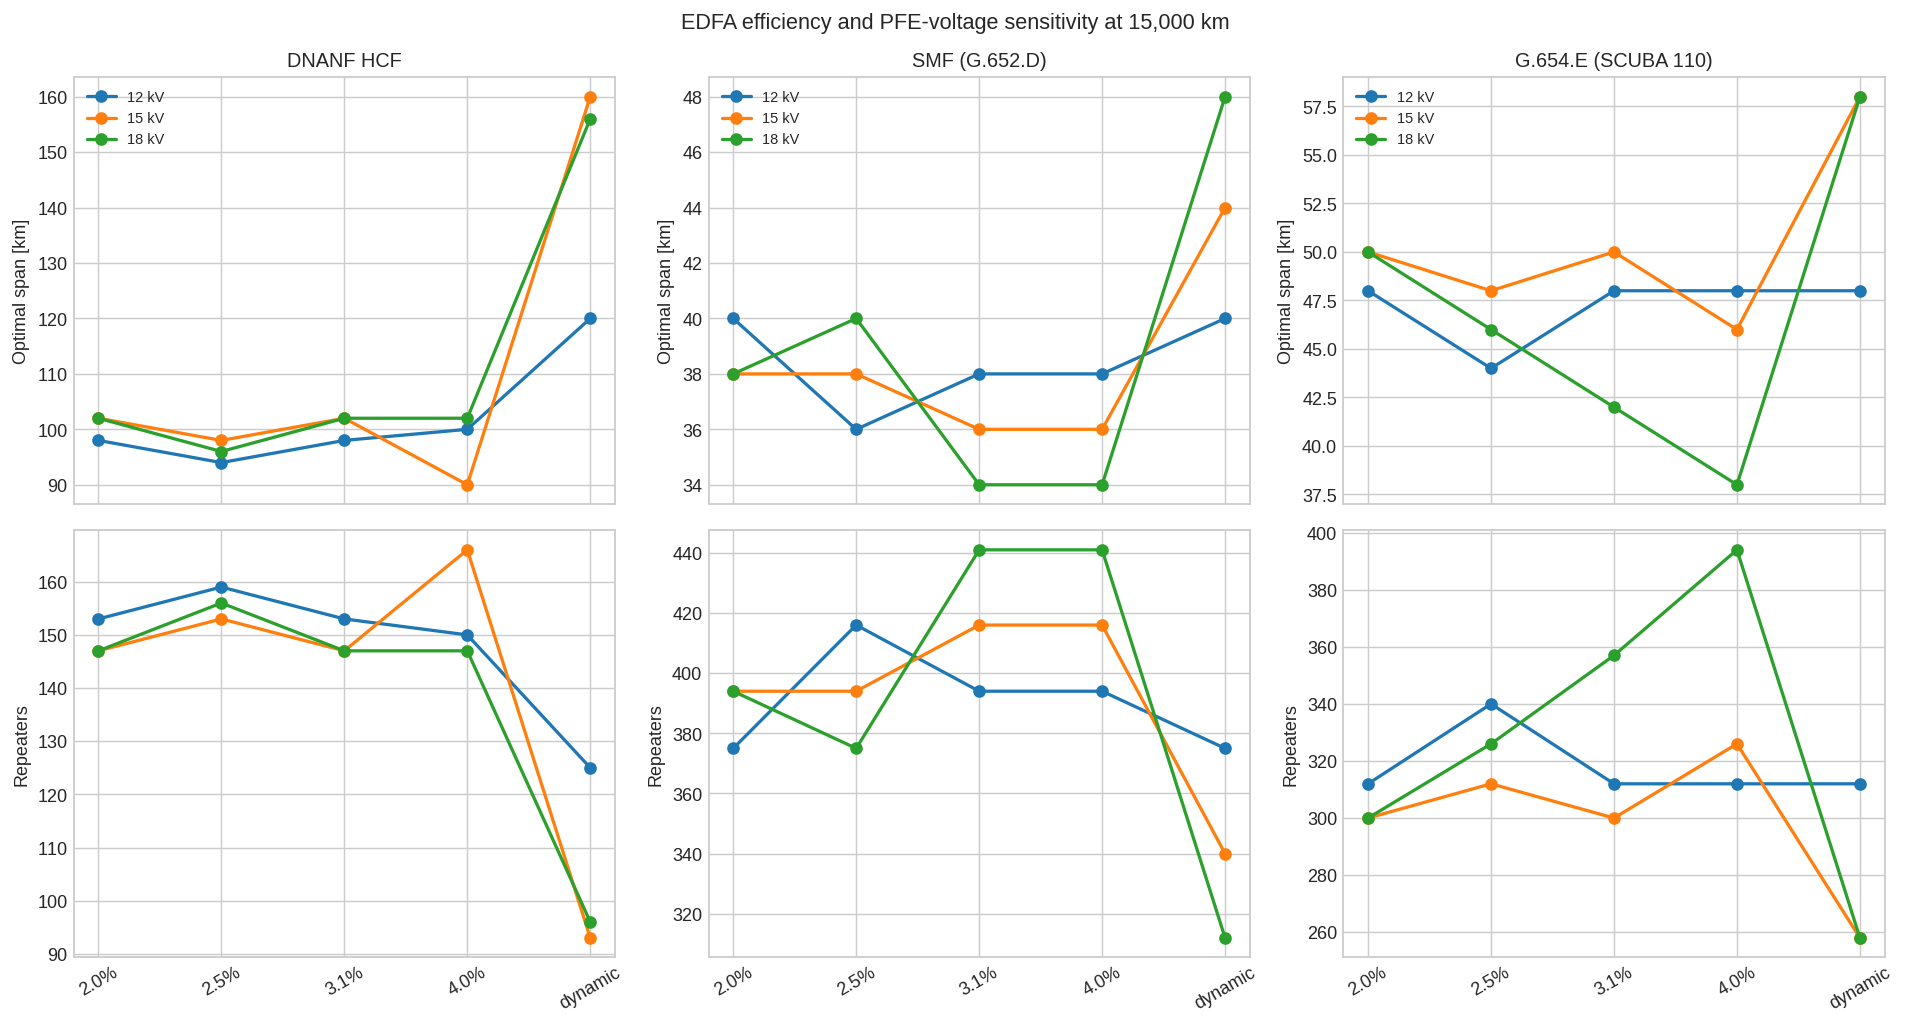

,fibre,span_min_km,span_max_km,repeaters_min,repeaters_max,gsnr_min_db,gsnr_max_db
0,G654E,38.0,50.0,300,394,8.108,10.971
1,HCF,96.0,102.0,147,156,8.569,9.245
2,SMF,34.0,40.0,375,441,6.373,9.199


Efficiency/PFE sensitivity checks: PASS


In [40]:
ETA_SCENARIOS = {
    "2.0%": make_fixed_eta_model(0.020),
    "2.5%": make_fixed_eta_model(0.025),
    "3.1%": make_fixed_eta_model(0.031),
    "4.0%": make_fixed_eta_model(0.040),
    "dynamic": eta_eo_surrogate,
}
PFE_VOLTAGES_KV = (12, 15, 18)
SENS_SPAN_GRID_KM = np.arange(10.0, 251.0, 2.0)
SENS_POWER_W = dbm_to_w(np.linspace(-30.0, 30.0, 601))

sensitivity_rows = []
for voltage_kv in PFE_VOLTAGES_KV:
    scenario_system = replace(SYSTEM, pfe_voltage_v=voltage_kv*1e3)
    for eta_label, eta_model in ETA_SCENARIOS.items():
        for key, fibre in FIBRES.items():
            best = optimize_span_journal(
                JOURNAL_LENGTH_KM, fibre, system=scenario_system,
                eta_model=eta_model, span_grid_km=SENS_SPAN_GRID_KM,
                power_search_w=SENS_POWER_W)
            best["eta_scenario"] = eta_label
            best["pfe_voltage_kv"] = voltage_kv
            sensitivity_rows.append(best)

PFE_SENSITIVITY = pd.DataFrame(sensitivity_rows)
display(PFE_SENSITIVITY[[
    "fibre", "pfe_voltage_kv", "eta_scenario", "optimal_gsnr_db",
    "nominal_span_km", "n_repeaters", "p_used_dbm",
    "active_constraint"]].round(3))

fig, axes = plt.subplots(2, 3, figsize=(14.8, 8.0), sharex=True)
eta_order = list(ETA_SCENARIOS)
x = np.arange(len(eta_order))
for col, (key, fibre) in enumerate(FIBRES.items()):
    d = PFE_SENSITIVITY[PFE_SENSITIVITY["fibre"]==key]
    for voltage in PFE_VOLTAGES_KV:
        q = d[d["pfe_voltage_kv"]==voltage].set_index(
            "eta_scenario").loc[eta_order]
        axes[0, col].plot(x, q["nominal_span_km"], "o-",
                          label=f"{voltage} kV")
        axes[1, col].plot(x, q["n_repeaters"], "o-",
                          label=f"{voltage} kV")
    axes[0, col].set_title(fibre.label)
    axes[0, col].set_ylabel("Optimal span [km]")
    axes[1, col].set_ylabel("Repeaters")
    axes[1, col].set_xticks(x, eta_order, rotation=30)
    axes[0, col].legend()
fig.suptitle("EDFA efficiency and PFE-voltage sensitivity at 15,000 km")
fig.tight_layout()
plt.show()

fixed18 = PFE_SENSITIVITY[
    (PFE_SENSITIVITY["pfe_voltage_kv"]==18)
    & (PFE_SENSITIVITY["eta_scenario"]!="dynamic")]
ETA_ENVELOPE_18KV = fixed18.groupby("fibre").agg(
    span_min_km=("nominal_span_km", "min"),
    span_max_km=("nominal_span_km", "max"),
    repeaters_min=("n_repeaters", "min"),
    repeaters_max=("n_repeaters", "max"),
    gsnr_min_db=("optimal_gsnr_db", "min"),
    gsnr_max_db=("optimal_gsnr_db", "max"),
).reset_index()
display(ETA_ENVELOPE_18KV.round(3))
assert np.all(PFE_SENSITIVITY["p_rep_required_w"]
              <= PFE_SENSITIVITY["p_rep_supplied_w"]+1e-9)
print("Efficiency/PFE sensitivity checks: PASS")


## 12. HCF attenuation–IMI 손익분기 경계

15,000 km에서 HCF attenuation과 IMI를 변화시키고 각 점마다 span과 launch power를 다시 최적화한다. G.654.E 기준도 동일 PFE 조건에서 최적화한다.

- ΔGSNR = GSNR(HCF) − GSNR(G.654.E)
- Repeater advantage = Nrep(G.654.E) − Nrep(HCF)
- 0-contour가 두 시스템의 손익분기 경계다.


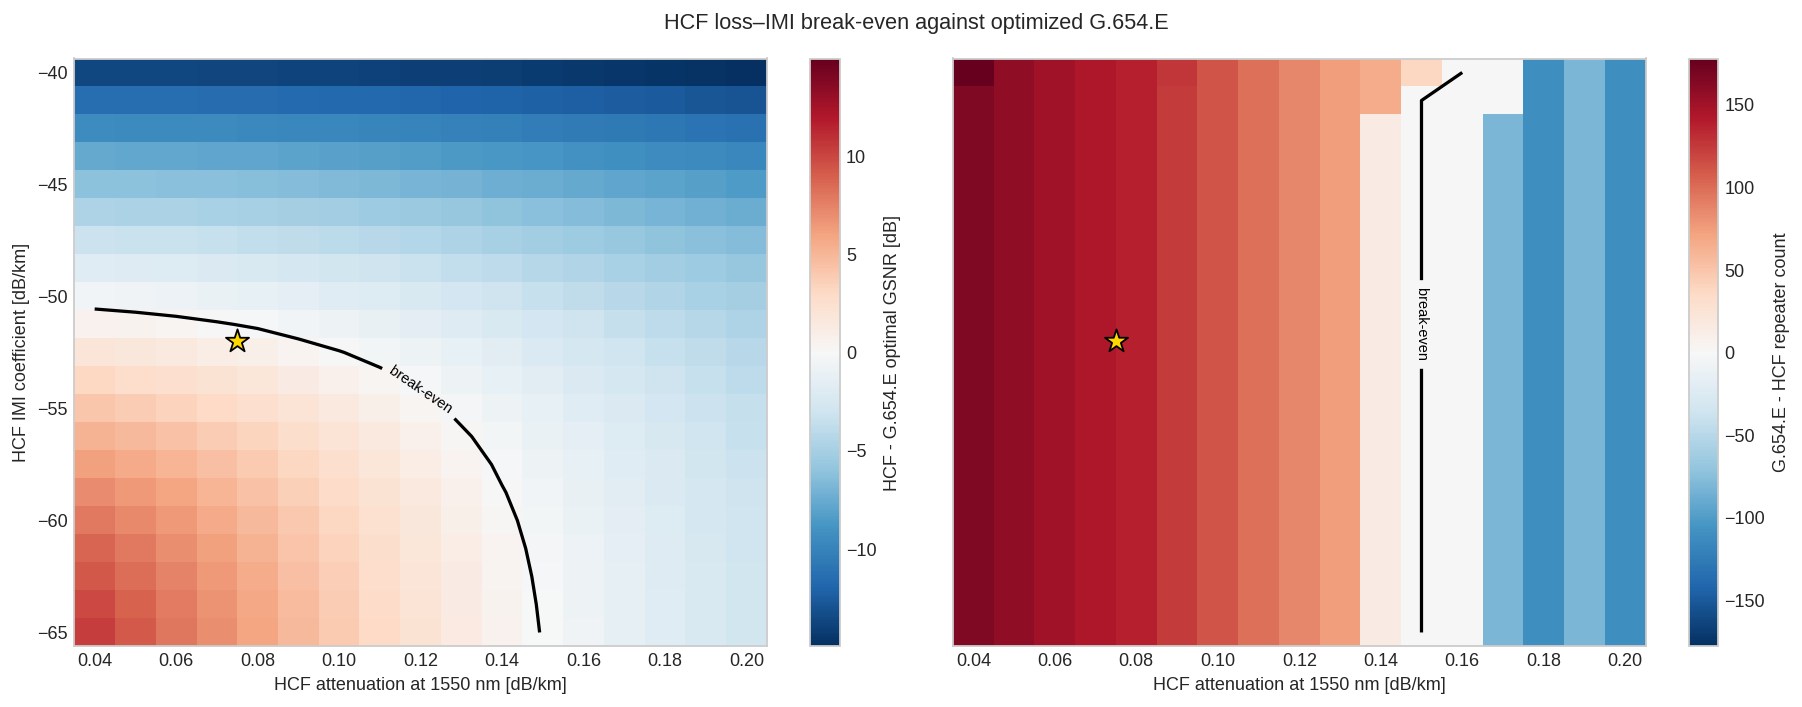

,HCF loss dB/km,maximum tolerable IMI dB/km,resolved_in_grid
0,0.04,-51.25,True
1,0.05,-51.25,True
2,0.06,-51.25,True
3,0.07,-51.25,True
4,0.08,-52.50,True
5,0.09,-52.50,True
6,0.10,-52.50,True
7,0.11,-53.75,True
8,0.12,-55.00,True
9,0.13,-56.25,True


HCF loss/IMI break-even checks: PASS


In [41]:
BREAK_LOSS_GRID = np.linspace(0.04, 0.20, 17)
BREAK_IMI_GRID = np.linspace(-65.0, -40.0, 21)
BREAK_SPAN_GRID = np.arange(15.0, 251.0, 4.0)
BREAK_POWER_W = FAST_POWER_W

g654_ref = optimize_span_journal(
    JOURNAL_LENGTH_KM, FIBRES["G654E"],
    span_grid_km=BREAK_SPAN_GRID, power_search_w=BREAK_POWER_W)

DELTA_GSNR_MAP = np.empty((len(BREAK_IMI_GRID), len(BREAK_LOSS_GRID)))
REPEATER_ADVANTAGE_MAP = np.empty_like(DELTA_GSNR_MAP)
HCF_SPAN_MAP = np.empty_like(DELTA_GSNR_MAP)

for iy, imi_db in enumerate(BREAK_IMI_GRID):
    for ix, loss_db in enumerate(BREAK_LOSS_GRID):
        variant = replace(FIBRES["HCF"],
                          attenuation_db_per_km=float(loss_db),
                          imi_db_per_km=float(imi_db))
        best = optimize_span_journal(
            JOURNAL_LENGTH_KM, variant,
            span_grid_km=BREAK_SPAN_GRID,
            power_search_w=BREAK_POWER_W)
        DELTA_GSNR_MAP[iy, ix] = (
            best["optimal_gsnr_db"]-g654_ref["optimal_gsnr_db"])
        REPEATER_ADVANTAGE_MAP[iy, ix] = (
            g654_ref["n_repeaters"]-best["n_repeaters"])
        HCF_SPAN_MAP[iy, ix] = best["nominal_span_km"]

def zero_centered_norm(values):
    lo, hi = float(np.nanmin(values)), float(np.nanmax(values))
    if lo < 0 < hi:
        m = max(abs(lo), abs(hi))
        return TwoSlopeNorm(vmin=-m, vcenter=0, vmax=m)
    return None

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.5), sharey=True)
for ax, values, label in [
    (axes[0], DELTA_GSNR_MAP, "HCF - G.654.E optimal GSNR [dB]"),
    (axes[1], REPEATER_ADVANTAGE_MAP,
     "G.654.E - HCF repeater count")]:
    mesh = ax.pcolormesh(BREAK_LOSS_GRID, BREAK_IMI_GRID, values,
                         shading="auto", cmap="RdBu_r",
                         norm=zero_centered_norm(values))
    if np.nanmin(values) <= 0 <= np.nanmax(values):
        cs = ax.contour(BREAK_LOSS_GRID, BREAK_IMI_GRID, values,
                        levels=[0], colors="black", linewidths=1.8)
        ax.clabel(cs, fmt={0: "break-even"}, fontsize=8)
    ax.scatter([FIBRES["HCF"].attenuation_db_per_km],
               [FIBRES["HCF"].imi_db_per_km],
               marker="*", s=180, color="gold", edgecolor="black")
    ax.set_xlabel("HCF attenuation at 1550 nm [dB/km]")
    fig.colorbar(mesh, ax=ax, label=label)
axes[0].set_ylabel("HCF IMI coefficient [dB/km]")
fig.suptitle("HCF loss–IMI break-even against optimized G.654.E")
fig.tight_layout()
plt.show()

boundary_rows = []
for ix, loss in enumerate(BREAK_LOSS_GRID):
    favourable = DELTA_GSNR_MAP[:, ix] >= 0
    threshold = (BREAK_IMI_GRID[np.flatnonzero(favourable)[-1]]
                 if np.any(favourable) else np.nan)
    boundary_rows.append({
        "HCF loss dB/km": loss,
        "maximum tolerable IMI dB/km": threshold,
        "resolved_in_grid": bool(np.any(favourable)
                                 and not np.all(favourable)),
    })
HCF_BREAK_EVEN_BOUNDARY = pd.DataFrame(boundary_rows)
display(HCF_BREAK_EVEN_BOUNDARY.round(4))
assert np.all(np.isfinite(DELTA_GSNR_MAP))
assert DELTA_GSNR_MAP.min() < 0 < DELTA_GSNR_MAP.max()
print("HCF loss/IMI break-even checks: PASS")


## 13. Monte Carlo 강건성 분석

아래 분포는 실제 제조 데이터가 없는 상태에서 코드의 불확실성 전파 기능을 검증하기 위한 illustrative prior다. 최종 투고 시 LS전선 측정 통계 또는 공급사 tolerance로 교체한다.

| 변수 | HCF 예시 분포 | G.654.E 예시 분포 |
|---|---:|---:|
| attenuation | 0.075±0.010 dB/km | 0.150±0.005 dB/km |
| dispersion | 3.2±0.3 ps/nm/km | 21.0±0.5 ps/nm/km |
| nonlinear coefficient | lognormal 10% | lognormal 5% |
| IMI | −52±3 dB/km | 미적용 |
| splice/FIFO loss per span | 0.20±0.05 dB | 0.10±0.03 dB |
| EDFA NF | 4.5±0.3 dB | 공통 표본 |
| eta_eo | uniform 2–4% | 공통 표본 |


,2.5%,median,97.5%
delta_GSNR_dB,-6.782,-0.937,3.58
HCF_span_km,72.000,96.000,124.00
HCF_repeaters,120.000,156.000,208.00
repeater_advantage,115.000,179.000,250.00


P(HCF GSNR > G.654.E) = 35.4%
P(HCF repeaters < G.654.E) = 100.0%


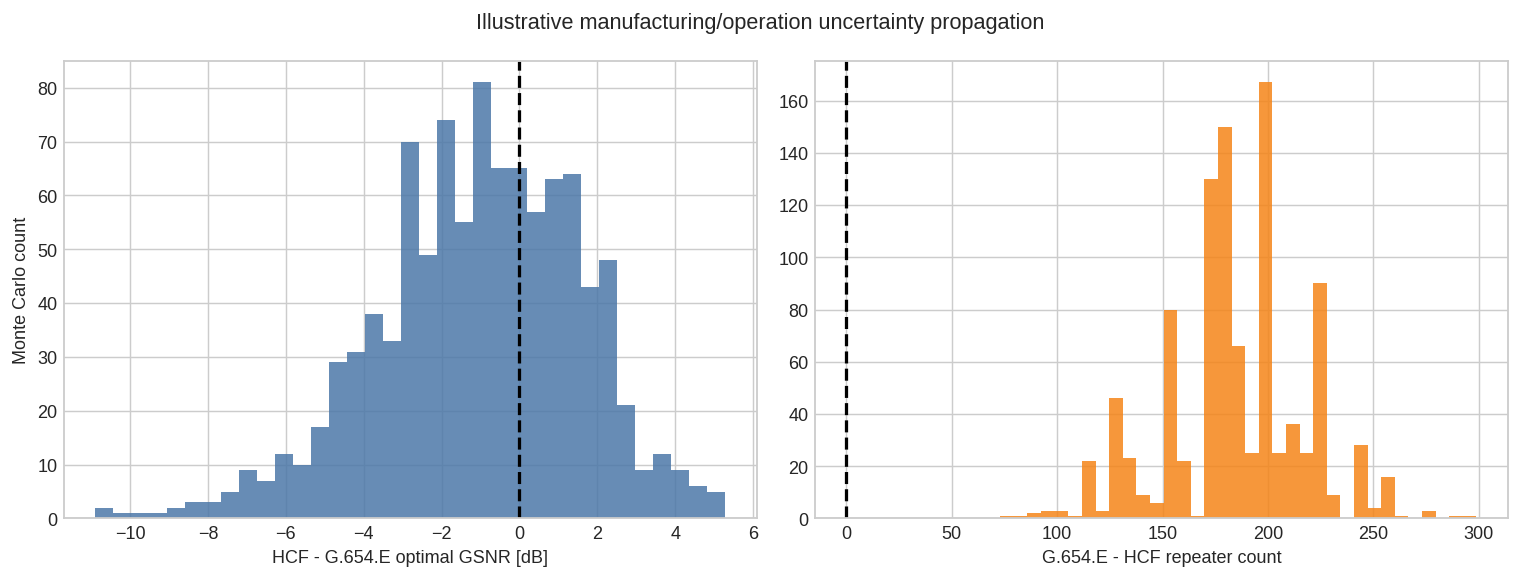

Monte Carlo reproducibility and finite-value checks: PASS


In [42]:
MC_SAMPLES = 1000
MC_SPAN_GRID = np.arange(20.0, 221.0, 4.0)
MC_POWER_W = dbm_to_w(np.linspace(-15.0, 22.0, 149))
mc_rng = np.random.default_rng(JOURNAL_SEED)

def clipped_normal(rng, mean, std, lower, upper):
    return float(np.clip(rng.normal(mean, std), lower, upper))

mc_rows = []
for sample in range(MC_SAMPLES):
    nf_db = clipped_normal(mc_rng, 4.5, 0.3, 3.5, 5.5)
    eta_fraction = float(mc_rng.uniform(0.020, 0.040))
    mc_system = replace(SYSTEM, noise_figure_db=nf_db)
    eta_model = make_fixed_eta_model(eta_fraction)

    hcf = replace(
        FIBRES["HCF"],
        attenuation_db_per_km=clipped_normal(
            mc_rng, 0.075, 0.010, 0.04, 0.12),
        dispersion_ps_nm_km=clipped_normal(
            mc_rng, 3.2, 0.3, 1.5, 5.0),
        gamma_per_w_km=float(
            FIBRES["HCF"].gamma_per_w_km*np.exp(mc_rng.normal(0, 0.10))),
        imi_db_per_km=clipped_normal(
            mc_rng, -52.0, 3.0, -65.0, -40.0),
    )
    g654 = replace(
        FIBRES["G654E"],
        attenuation_db_per_km=clipped_normal(
            mc_rng, 0.150, 0.005, 0.135, 0.170),
        dispersion_ps_nm_km=clipped_normal(
            mc_rng, 21.0, 0.5, 19.0, 23.0),
        gamma_per_w_km=float(
            FIBRES["G654E"].gamma_per_w_km*np.exp(mc_rng.normal(0, 0.05))),
    )
    hcf_extra = clipped_normal(mc_rng, 0.20, 0.05, 0.05, 0.40)
    g654_extra = clipped_normal(mc_rng, 0.10, 0.03, 0.02, 0.25)

    hcf_best = optimize_span_journal(
        JOURNAL_LENGTH_KM, hcf, system=mc_system,
        eta_model=eta_model, span_grid_km=MC_SPAN_GRID,
        power_search_w=MC_POWER_W, extra_span_loss_db=hcf_extra)
    g654_best = optimize_span_journal(
        JOURNAL_LENGTH_KM, g654, system=mc_system,
        eta_model=eta_model, span_grid_km=MC_SPAN_GRID,
        power_search_w=MC_POWER_W, extra_span_loss_db=g654_extra)
    mc_rows.append({
        "sample": sample,
        "eta_eo": eta_fraction, "NF_dB": nf_db,
        "HCF_GSNR_dB": hcf_best["optimal_gsnr_db"],
        "G654E_GSNR_dB": g654_best["optimal_gsnr_db"],
        "delta_GSNR_dB": (hcf_best["optimal_gsnr_db"]
                          - g654_best["optimal_gsnr_db"]),
        "HCF_span_km": hcf_best["nominal_span_km"],
        "G654E_span_km": g654_best["nominal_span_km"],
        "HCF_repeaters": hcf_best["n_repeaters"],
        "G654E_repeaters": g654_best["n_repeaters"],
        "repeater_advantage": (g654_best["n_repeaters"]
                               - hcf_best["n_repeaters"]),
    })

MONTE_CARLO_RESULTS = pd.DataFrame(mc_rows)
mc_summary = MONTE_CARLO_RESULTS[[
    "delta_GSNR_dB", "HCF_span_km", "HCF_repeaters",
    "repeater_advantage"]].quantile([0.025, 0.5, 0.975]).T
mc_summary.columns = ["2.5%", "median", "97.5%"]
display(mc_summary.round(3))

PROB_HCF_GSNR_ADVANTAGE = float(
    np.mean(MONTE_CARLO_RESULTS["delta_GSNR_dB"] > 0))
PROB_HCF_REPEATER_ADVANTAGE = float(
    np.mean(MONTE_CARLO_RESULTS["repeater_advantage"] > 0))
print(f"P(HCF GSNR > G.654.E) = {100*PROB_HCF_GSNR_ADVANTAGE:.1f}%")
print(f"P(HCF repeaters < G.654.E) = "
      f"{100*PROB_HCF_REPEATER_ADVANTAGE:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
axes[0].hist(MONTE_CARLO_RESULTS["delta_GSNR_dB"],
             bins=35, color="#4c78a8", alpha=0.85)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_xlabel("HCF - G.654.E optimal GSNR [dB]")
axes[0].set_ylabel("Monte Carlo count")
axes[1].hist(MONTE_CARLO_RESULTS["repeater_advantage"],
             bins=35, color="#f58518", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("G.654.E - HCF repeater count")
fig.suptitle("Illustrative manufacturing/operation uncertainty propagation")
fig.tight_layout()
plt.show()

assert len(MONTE_CARLO_RESULTS) == MC_SAMPLES
assert MONTE_CARLO_RESULTS.replace([np.inf, -np.inf], np.nan).notna().all().all()
print("Monte Carlo reproducibility and finite-value checks: PASS")


## 14. Capacity·energy/bit 및 wet-plant 복잡도 보조 지표

이상적 dual-polarization Shannon upper bound를 사용한다. 실제 AIR/GMI에는 modulation, FEC, implementation penalty가 추가되어야 한다. Repeater count는 wet-plant 비용의 대리변수일 뿐 실제 TCO가 아니다.


,fibre,ideal_capacity_Tb_s,total_repeater_electrical_kW,energy_pJ_bit,repeaters_as_wet_plant_proxy
0,HCF,284.9209,5.3712,18.8516,97
1,SMF,222.3019,5.3995,24.2891,375
2,G654E,268.4715,5.3957,20.0977,258


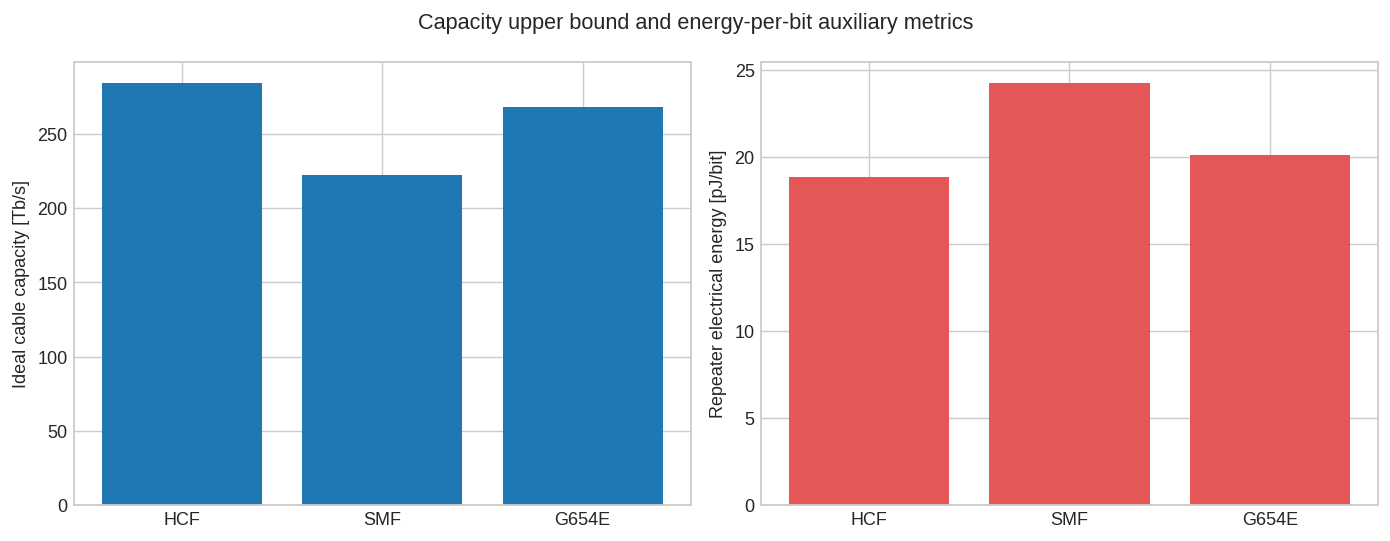

In [43]:
capacity_rows = []
for _, row in CANONICAL_RESULTS.iterrows():
    gsnr_lin = float(db_to_lin(row["optimal_gsnr_db"]))
    capacity_per_pair_bps = (
        2*SYSTEM.symbol_rate_hz*SYSTEM.n_channels*np.log2(1+gsnr_lin))
    cable_capacity_bps = SYSTEM.fibre_pairs*capacity_per_pair_bps
    total_repeater_electrical_w = (
        row["n_repeaters"]*row["p_rep_required_w"])
    energy_j_bit = total_repeater_electrical_w/cable_capacity_bps
    capacity_rows.append({
        "fibre": row["fibre"],
        "ideal_capacity_Tb_s": cable_capacity_bps/1e12,
        "total_repeater_electrical_kW": total_repeater_electrical_w/1e3,
        "energy_pJ_bit": energy_j_bit*1e12,
        "repeaters_as_wet_plant_proxy": row["n_repeaters"],
    })
CAPACITY_ENERGY_RESULTS = pd.DataFrame(capacity_rows)
display(CAPACITY_ENERGY_RESULTS.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))
axes[0].bar(CAPACITY_ENERGY_RESULTS["fibre"],
            CAPACITY_ENERGY_RESULTS["ideal_capacity_Tb_s"])
axes[0].set_ylabel("Ideal cable capacity [Tb/s]")
axes[1].bar(CAPACITY_ENERGY_RESULTS["fibre"],
            CAPACITY_ENERGY_RESULTS["energy_pJ_bit"], color="#e45756")
axes[1].set_ylabel("Repeater electrical energy [pJ/bit]")
fig.suptitle("Capacity upper bound and energy-per-bit auxiliary metrics")
fig.tight_layout()
plt.show()


## 15. 자동 논문 결과 요약 및 주장 범위


In [44]:
hcf_row = CANONICAL_RESULTS[CANONICAL_RESULTS["fibre"]=="HCF"].iloc[0]
g654_row = CANONICAL_RESULTS[CANONICAL_RESULTS["fibre"]=="G654E"].iloc[0]
smf_row = CANONICAL_RESULTS[CANONICAL_RESULTS["fibre"]=="SMF"].iloc[0]
g654_reduction = 100*(g654_row["n_repeaters"]-hcf_row["n_repeaters"])/g654_row["n_repeaters"]
smf_reduction = 100*(smf_row["n_repeaters"]-hcf_row["n_repeaters"])/smf_row["n_repeaters"]

orig_fig12 = fig12_metrics[fig12_metrics["Comparison"] == "Original closed GN vs paper GN"]
fig12_weighted_rmse = float(np.sqrt(np.average(orig_fig12["RMSE [dB]"]**2)))
fig12_mean_bias = float(orig_fig12["bias [dB]"].mean())
fig12_max = float(orig_fig12["max |error| [dB]"].max())
all_fig3_err = []
for mod in ("QPSK", "16QAM"):
    for name in PAPER_REACH_FIBRES:
        pred = fig3_predictions[mod][name]
        ref = np.array(PAPER_FIG3[mod][name]["SIM"])
        all_fig3_err.extend(10*np.log10(pred/ref))
all_fig3_err = np.asarray(all_fig3_err)
fig3_all_rmse = float(np.sqrt(np.mean(all_fig3_err**2)))
fig3_all_bias = float(np.mean(all_fig3_err))
fig3_all_max = float(np.max(np.abs(all_fig3_err)))
SSFM_MEDIAN_DELTA_DB = float(np.median(SSFM_VALIDATION["SSFM_minus_GN_dB"]))

print("="*96)
print("DOMESTIC-JOURNAL SIMULATION SUMMARY")
print("="*96)
print(f"Paper Fig.1/2 closed-GN NLI RMSE: {fig12_weighted_rmse:.3f} dB")
print(f"Paper Fig.3 reach RMSE: {fig3_all_rmse:.3f} dB; "
      f"max error: {fig3_all_max:.3f} dB")
print(f"Corrected GN vs flat-GGN max mismatch: "
      f"{flat_equiv_error_db.max():.3f} dB")
print(f"321 vs 1281 grid max |error|: {grid_321_abs:.3f} dB")
print(f"Channel-aligned 8 vs 32 points/channel max |error|: "
      f"{grid_aligned_8ppc_abs:.3f} dB")
print(f"Representative SSFM cubic slope: {SSFM_CUBIC_SLOPE:.3f}")
print(f"Representative SSFM median eta offset vs GN: "
      f"{SSFM_MEDIAN_DELTA_DB:.3f} dB")
print(f"15,000-km HCF: GSNR={hcf_row['optimal_gsnr_db']:.3f} dB, "
      f"span={hcf_row['nominal_span_km']:.0f} km, "
      f"repeaters={int(hcf_row['n_repeaters'])}")
print(f"HCF repeater reduction: {g654_reduction:.1f}% vs G.654.E, "
      f"{smf_reduction:.1f}% vs G.652.D")
print(f"Illustrative Monte Carlo P(GSNR advantage)="
      f"{100*PROB_HCF_GSNR_ADVANTAGE:.1f}%, "
      f"P(repeater advantage)={100*PROB_HCF_REPEATER_ADVANTAGE:.1f}%")

journal_comment = f"""
### 논문용 해석

1. **재현 정확도:** 문헌 Fig. 3 reach RMSE는 {fig3_all_rmse:.3f} dB로 양호하지만,
   Fig. 1/2 NLI 계수 RMSE {fig12_weighted_rmse:.3f} dB는 저분산·소채널 조건에서
   coherent accumulation 한계를 포함한다.
2. **수치 신뢰도:** 기존 whole-band 321-point 적분은 1281-point 내부 기준 대비 최대
   {grid_321_abs:.3f} dB 차이를 보였고, channel-aligned 8 points/channel 적분은
   32 points/channel 기준 대비 {grid_aligned_8ppc_abs:.3f} dB 차이를 보였다.
   최종 표에는 channel-aligned 수렴값과 수렴 오차를 함께 기재한다.
3. **독립 검산:** waveform SSFM의 NLI power-law slope는
   {SSFM_CUBIC_SLOPE:.3f}이고 GN 대비 median eta offset은
   {SSFM_MEDIAN_DELTA_DB:.3f} dB이다. QPSK modulation statistics와 scalar single-span 설정을 포함하므로
   이는 cubic NLI scaling sanity check이며 full-field 실험 검증이 아니다.
4. **설계 기여:** HCF loss–IMI break-even map은 특정 성능값 하나보다
   HCF가 G.654.E보다 유리해지는 제조·운용 경계를 제시한다.
5. **불확실성:** Monte Carlo 수치는 illustrative prior 기반이다. 실제 HCF loss/IMI,
   splice/FIFO 및 EDFA efficiency 통계로 교체하기 전에는 공식 제품 성능 확률로 주장하지 않는다.
6. **비용 해석:** repeater count와 energy/bit은 비교 가능하지만, 실제 wet-plant TCO는
   repeater·branching unit·joint·installation 단가를 확보한 뒤 별도 계산한다.
"""
display(Markdown(journal_comment))

assert flat_equiv_error_db.max() < 0.5
assert fig3_all_rmse < 0.5
assert np.isfinite(grid_321_abs)
assert np.isfinite(grid_aligned_8ppc_abs)
assert 2.0 < SSFM_CUBIC_SLOPE < 4.0
assert len(MONTE_CARLO_RESULTS) == MC_SAMPLES
print("All domestic-journal extension assertions: PASS")


DOMESTIC-JOURNAL SIMULATION SUMMARY
Paper Fig.1/2 closed-GN NLI RMSE: 0.962 dB
Paper Fig.3 reach RMSE: 0.261 dB; max error: 0.647 dB
Corrected GN vs flat-GGN max mismatch: 0.000 dB
321 vs 1281 grid max |error|: 5.857 dB
Channel-aligned 8 vs 32 points/channel max |error|: 1.568 dB
Representative SSFM cubic slope: 3.000
Representative SSFM median eta offset vs GN: -2.806 dB
15,000-km HCF: GSNR=8.814 dB, span=154 km, repeaters=97
HCF repeater reduction: 62.4% vs G.654.E, 74.1% vs G.652.D
Illustrative Monte Carlo P(GSNR advantage)=35.4%, P(repeater advantage)=100.0%



### 논문용 해석

1. **재현 정확도:** 문헌 Fig. 3 reach RMSE는 0.261 dB로 양호하지만,
   Fig. 1/2 NLI 계수 RMSE 0.962 dB는 저분산·소채널 조건에서
   coherent accumulation 한계를 포함한다.
2. **수치 신뢰도:** 기존 whole-band 321-point 적분은 1281-point 내부 기준 대비 최대
   5.857 dB 차이를 보였고, channel-aligned 8 points/channel 적분은
   32 points/channel 기준 대비 1.568 dB 차이를 보였다.
   최종 표에는 channel-aligned 수렴값과 수렴 오차를 함께 기재한다.
3. **독립 검산:** waveform SSFM의 NLI power-law slope는
   3.000이고 GN 대비 median eta offset은
   -2.806 dB이다. QPSK modulation statistics와 scalar single-span 설정을 포함하므로
   이는 cubic NLI scaling sanity check이며 full-field 실험 검증이 아니다.
4. **설계 기여:** HCF loss–IMI break-even map은 특정 성능값 하나보다
   HCF가 G.654.E보다 유리해지는 제조·운용 경계를 제시한다.
5. **불확실성:** Monte Carlo 수치는 illustrative prior 기반이다. 실제 HCF loss/IMI,
   splice/FIFO 및 EDFA efficiency 통계로 교체하기 전에는 공식 제품 성능 확률로 주장하지 않는다.
6. **비용 해석:** repeater count와 energy/bit은 비교 가능하지만, 실제 wet-plant TCO는
   repeater·branching unit·joint·installation 단가를 확보한 뒤 별도 계산한다.


All domestic-journal extension assertions: PASS


## 16. 출처 및 최종 투고 전 교체 자료

- 원 코드: https://github.com/kimheeseo/LSCNS/blob/main/GN_GGN_Cross_Validation_Precision_Verification_Execution.ipynb
- GN/GGN MATLAB: https://github.com/kimheeseo/LSCNS/tree/main/GNmodelPJT
- P. Poggiolini et al., The GN-model of fiber non-linear propagation and its applications, JLT, 2014.
- P. Poggiolini et al., A simple and accurate closed-form EGN model formula, 2015.
- D. Semrau et al., ISRS GN-model references for ultra-wideband power-profile validation.
- 최종 투고 전 필요: 실제 eta_eo(gain, output), HCF attenuation/IMI/splice/FIFO 통계, 독립 SSFM 설정표 또는 측정 데이터.

### 재현성

- 고정 난수 seed: 20260823
- Monte Carlo 기본 표본: 1000
- canonical optimization: span 1 km, launch power 0.05 dB 간격
- 민감도/break-even/Monte Carlo는 계산시간을 위해 별도 coarse grid를 사용하며 각 셀에 간격을 명시한다.
